# PD Model Train

In [1]:
import numpy as np
import pandas as pd

In [2]:
#df_input_prep = pd.read_pickle('/Users/eileending/Downloads/input_train.pkl')
#df_target_prep = pd.read_pickle('/Users/eileending/Downloads/target_train.pkl')
df_input_prep = pd.read_pickle('/Users/eileending/Downloads/input_test.pkl')
df_target_prep = pd.read_pickle('/Users/eileending/Downloads/target_test.pkl')

In [3]:
df1 = pd.concat([df_input_prep['grade'],df_target_prep], axis=1)

In [4]:
# % of good borrowers
df_grade = pd.concat([df1.groupby(df1.columns.values[0],as_index = False)[df1.columns.values[1]].count(), 
                      df1.groupby(df1.columns.values[0],as_index = False)[df1.columns.values[1]].mean()],axis=1)

In [5]:
df_grade = df_grade.iloc[:,[0,1,3]]

In [6]:
df_grade.columns = [df_grade.columns.values[0],'n_obs','prop_good']

In [7]:
df_grade['prop_n_obs'] = df_grade['n_obs']/df_grade['n_obs'].sum()
df_grade

,grade,n_obs,prop_good,prop_n_obs
0,A,15108,0.962338,0.162004
1,B,27199,0.923085,0.291656
2,C,25048,0.882905,0.268591
3,D,15390,0.844314,0.165028
4,E,7145,0.805178,0.076616
5,F,2699,0.775472,0.028942
6,G,668,0.697605,0.007163


In [8]:
df_grade['n_good'] = df_grade['prop_good']*df_grade['n_obs']
df_grade['n_bad'] = (1-df_grade['prop_good'])*df_grade['n_obs']
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,15108,0.962338,0.162004,14539.0,569.0
1,B,27199,0.923085,0.291656,25107.0,2092.0
2,C,25048,0.882905,0.268591,22115.0,2933.0
3,D,15390,0.844314,0.165028,12994.0,2396.0
4,E,7145,0.805178,0.076616,5753.0,1392.0
5,F,2699,0.775472,0.028942,2093.0,606.0
6,G,668,0.697605,0.007163,466.0,202.0


In [9]:
df_grade['prop_n_good'] = df_grade['n_good']/df_grade['n_good'].sum()
df_grade['prop_n_bad'] = df_grade['n_bad']/df_grade['n_bad'].sum()
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,15108,0.962338,0.162004,14539.0,569.0,0.175027,0.055839
1,B,27199,0.923085,0.291656,25107.0,2092.0,0.302250,0.205299
2,C,25048,0.882905,0.268591,22115.0,2933.0,0.266231,0.287831
3,D,15390,0.844314,0.165028,12994.0,2396.0,0.156428,0.235132
4,E,7145,0.805178,0.076616,5753.0,1392.0,0.069257,0.136605
5,F,2699,0.775472,0.028942,2093.0,606.0,0.025197,0.059470
6,G,668,0.697605,0.007163,466.0,202.0,0.005610,0.019823


In [10]:
df_grade['WoE'] = np.log(df_grade['prop_n_good']/df_grade['prop_n_bad'])
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,A,15108,0.962338,0.162004,14539.0,569.0,0.175027,0.055839,1.142469
1,B,27199,0.923085,0.291656,25107.0,2092.0,0.302250,0.205299,0.386785
2,C,25048,0.882905,0.268591,22115.0,2933.0,0.266231,0.287831,-0.078010
3,D,15390,0.844314,0.165028,12994.0,2396.0,0.156428,0.235132,-0.407554
4,E,7145,0.805178,0.076616,5753.0,1392.0,0.069257,0.136605,-0.679261
5,F,2699,0.775472,0.028942,2093.0,606.0,0.025197,0.059470,-0.858767
6,G,668,0.697605,0.007163,466.0,202.0,0.005610,0.019823,-1.262323


In [11]:
df_grade['IV'] = ((df_grade['prop_n_good']-df_grade['prop_n_bad']) * df_grade['WoE']).sum()

In [12]:
df_grade

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,A,15108,0.962338,0.162004,14539.0,569.0,0.175027,0.055839,1.142469,0.300551
1,B,27199,0.923085,0.291656,25107.0,2092.0,0.302250,0.205299,0.386785,0.300551
2,C,25048,0.882905,0.268591,22115.0,2933.0,0.266231,0.287831,-0.078010,0.300551
3,D,15390,0.844314,0.165028,12994.0,2396.0,0.156428,0.235132,-0.407554,0.300551
4,E,7145,0.805178,0.076616,5753.0,1392.0,0.069257,0.136605,-0.679261,0.300551
5,F,2699,0.775472,0.028942,2093.0,606.0,0.025197,0.059470,-0.858767,0.300551
6,G,668,0.697605,0.007163,466.0,202.0,0.005610,0.019823,-1.262323,0.300551


In [13]:
# automate for all categorical variables (Macro)

In [14]:
def woe_cal(df, disc_var_name, good_bad_var_df):
    df = pd.concat([df[disc_var_name],good_bad_var_df], axis=1)
    df = pd.concat([df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].count(), 
                      df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].mean()],axis=1)
    df = df.iloc[:,[0,1,3]]
    df.columns = [df.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs'] = df['n_obs']/df['n_obs'].sum()
    df['n_good'] = df['prop_good']*df['n_obs']
    df['n_bad'] = (1-df['prop_good'])*df['n_obs']
    df['prop_n_good'] = df['n_good']/df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad']/df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good']/df['prop_n_bad'])
    df['IV'] = ((df['prop_n_good']-df['prop_n_bad']) * df['WoE']).sum()
    return df

In [15]:
df_sub_grade = woe_cal(df_input_prep, 'sub_grade', df_target_prep)
df_homeown = woe_cal(df_input_prep, 'home_ownership', df_target_prep)
df_verif_sts = woe_cal(df_input_prep, 'verification_status', df_target_prep)
df_addr_state = woe_cal(df_input_prep, 'addr_state', df_target_prep)
df_ini_sts = woe_cal(df_input_prep, 'initial_list_status', df_target_prep)

/opt/miniconda3/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Visulization

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [17]:
def plot_by_woe(df_WoE, rotation_of_x_axis=0):
    x = np.array(df_WoE.iloc[:,0].apply(str))
    y = df_WoE['WoE']
    plt.figure(figsize=(18,6))
    plt.plot(x,y,marker='o',linestyle = '--',color='k')
    plt.xlabel(df_WoE.columns[0])
    plt.title(str('WoE by '+ df_WoE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis)

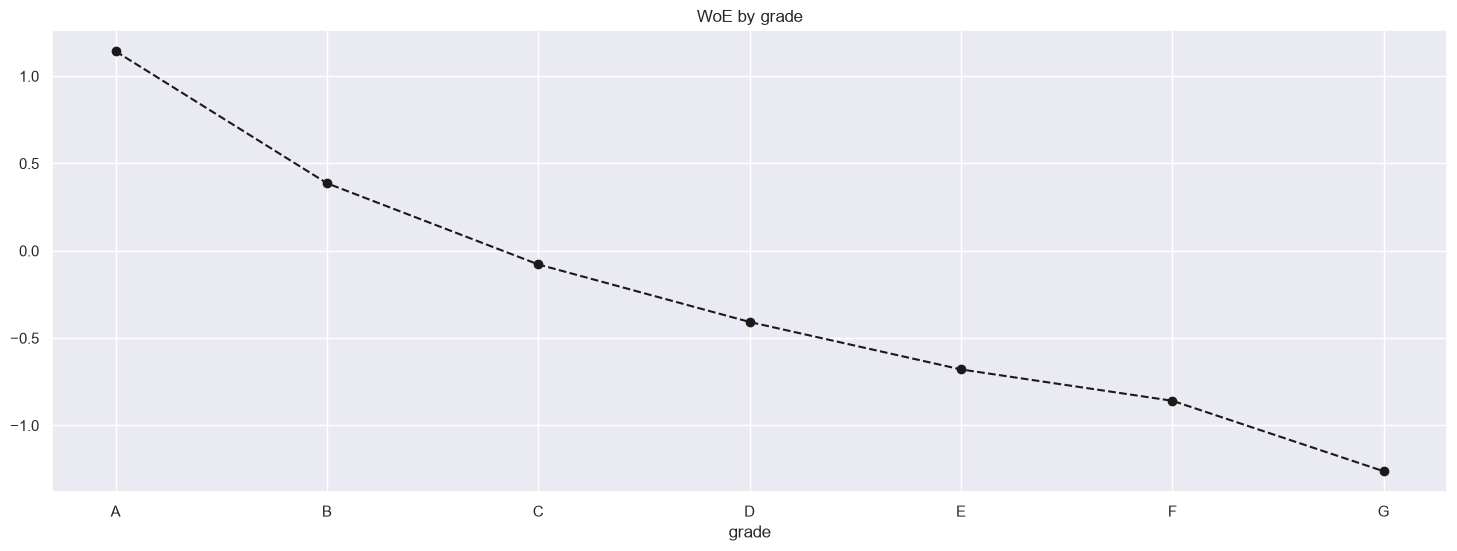

In [18]:

# Analyze the plot and data one by one
# 1. grade 
plot_by_woe(df_grade)
# reference grade_G, grade_A to grade_F used as independent variable

In [19]:
# 2. Home Owner 
df_homeown
# 'Any' has only 1, 'None' and 'Other' are very few, combine them all with 'Rent' (smallest group), with higher default rate

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,MORTGAGE,46919,0.904751,0.503115,42450.0,4469.0,0.511033,0.438567,0.152922,0.022938
1,NONE,10,0.800000,0.000107,8.0,2.0,0.000096,0.000196,-0.711946,0.022938
2,OTHER,45,0.777778,0.000483,35.0,10.0,0.000421,0.000981,-0.845478,0.022938
3,OWN,8409,0.888572,0.090170,7472.0,937.0,0.089951,0.091953,-0.022006,0.022938
4,RENT,37874,0.874003,0.406125,33102.0,4772.0,0.398498,0.468302,-0.161412,0.022938


In [20]:
df_input_prep['home_ownership_RONA'] = df_input_prep[['home_ownership_RENT','home_ownership_ANY',
                                                     'home_ownership_NONE','home_ownership_OTHER']].sum(axis=1)

In [21]:
x = df_input_prep['home_ownership_RONA'].sum()

print(x)

37929


In [22]:
# 3. addr_state
df_input_prep['addr_state'].unique()

<StringArray>
['CA', 'IN', 'AZ', 'MI', 'PA', 'MO', 'CT', 'IL', 'SC', 'VA', 'NY', 'FL', 'TX',
 'NC', 'NM', 'NJ', 'KY', 'DE', 'OK', 'CO', 'OH', 'GA', 'LA', 'WA', 'AL', 'TN',
 'MD', 'NV', 'MN', 'RI', 'NH', 'MA', 'MS', 'UT', 'WV', 'HI', 'KS', 'OR', 'WY',
 'WI', 'AK', 'DC', 'AR', 'MT', 'SD', 'VT', 'IA', 'ID', 'ME', 'NE']
Length: 50, dtype: str

In [23]:
if 'addr_state_ND' in df_input_prep.columns.values:
    pass
else:
    df_input_prep['addr_state_ND'] = 0
# redo the WoE with the newly added ND
df_addr_state = woe_cal(df_input_prep, 'addr_state', df_target_prep)

/opt/miniconda3/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [24]:
df_addr_state = df_addr_state.sort_values('WoE').reset_index(drop=True)
df_addr_state

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,NE,1,0.000000,0.000011,0.0,1.0,0.000000,0.000098,-inf,inf
1,ID,2,0.500000,0.000021,1.0,1.0,0.000012,0.000098,-2.098241,inf
2,NV,1298,0.855932,0.013919,1111.0,187.0,0.013375,0.018351,-0.316333,inf
3,HI,486,0.860082,0.005211,418.0,68.0,0.005032,0.006673,-0.282267,inf
4,FL,6426,0.870059,0.068906,5591.0,835.0,0.067307,0.081943,-0.196759,inf
5,AL,1182,0.873096,0.012675,1032.0,150.0,0.012424,0.014720,-0.169622,inf
6,NJ,3676,0.875408,0.039418,3218.0,458.0,0.038740,0.044946,-0.148595,inf
7,LA,1130,0.876106,0.012117,990.0,140.0,0.011918,0.013739,-0.142178,inf
8,NY,8031,0.879965,0.086117,7067.0,964.0,0.085076,0.094603,-0.106141,inf
9,RI,403,0.880893,0.004321,355.0,48.0,0.004274,0.004711,-0.097324,inf


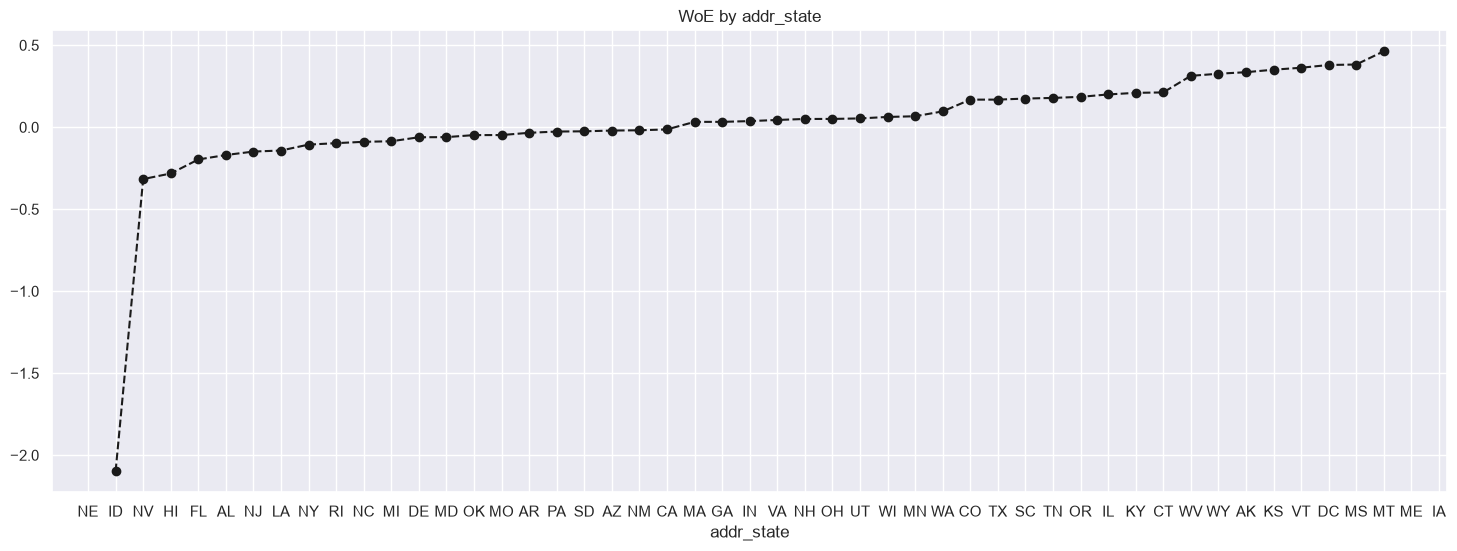

In [25]:
plot_by_woe(df_addr_state)

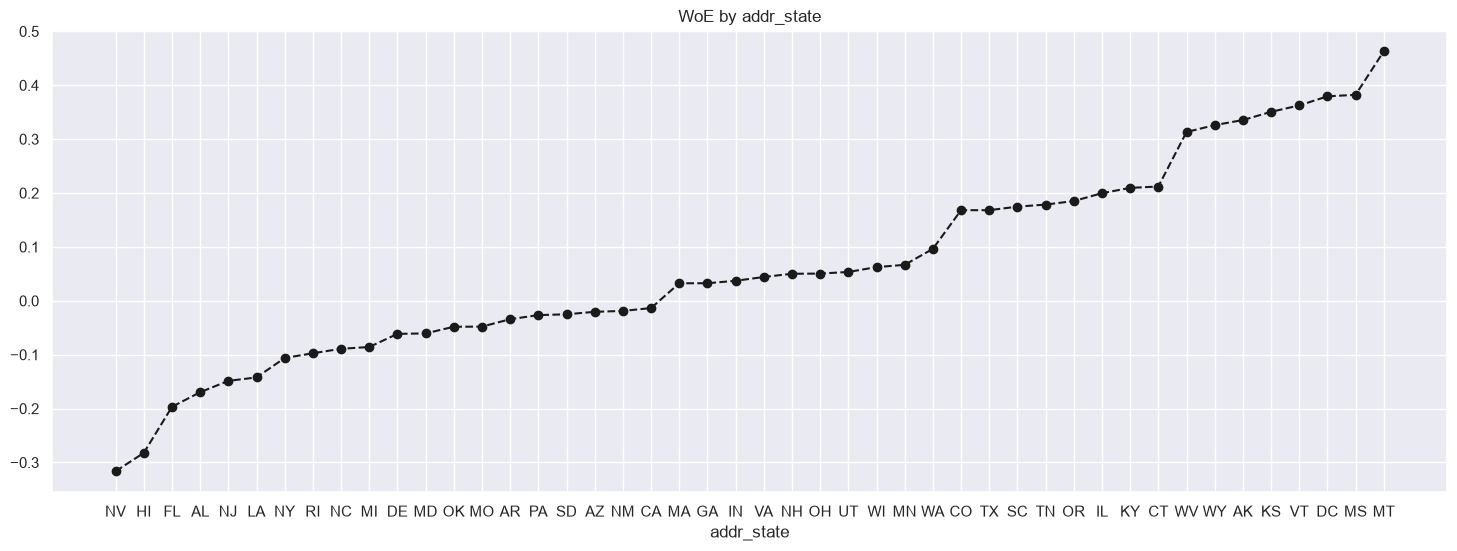

In [26]:
plot_by_woe(df_addr_state.iloc[2: -2, :])

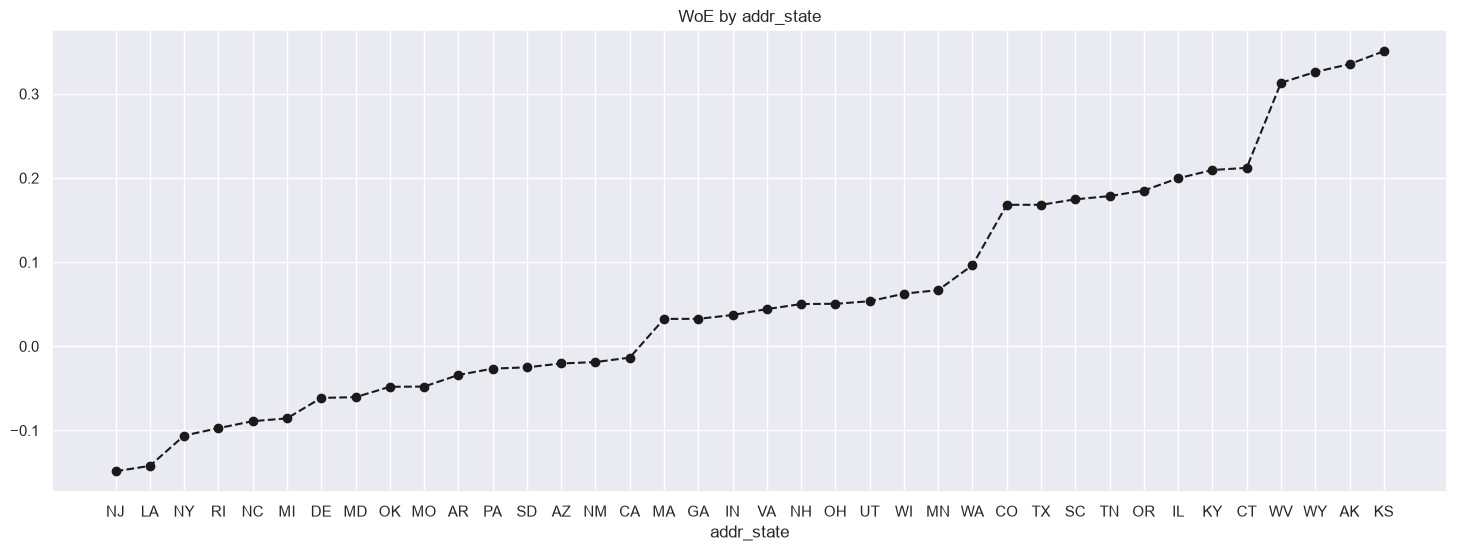

In [27]:
# group the first 6 and last 6 by both number of obs and WoE based on the plot and the data
plot_by_woe(df_addr_state.iloc[6: -6, :])

In [28]:
# group further still by number of observation and WoE
# NY and CA having many observations, thus (6,2, NY, 6, CA, 4,5,5,3,2,TX,2,6,6(1 more of the not existing)) 
recategory = ['ND_NE_IA_NV_FL_HI_AL','NM_VA','NY','OK_TN_MO_LA_MD_NC','CA','UT_KY_AZ_NJ','AR_MI_PA_OH_MN','RI_MA_DE_SD_IN',
        'GA_WA_OR', 'WI_MT','TX','IL_CT','KS_SC_CO_VT_AK_MS','WV_NH_WY_DC_ME_ID']
df_input_prep['addr_state_ND_NE_IA_NV_FL_HI_AL'] = df_input_prep[['addr_state_ND','addr_state_NE','addr_state_IA','addr_state_NV','addr_state_FL',
    'addr_state_HI','addr_state_AL']].sum(axis=1)
df_input_prep['addr_state_NM_VA'] = df_input_prep[['addr_state_NM','addr_state_VA']].sum(axis=1)
df_input_prep['addr_state_OK_TN_MO_LA_MD_NC'] = df_input_prep[['addr_state_OK','addr_state_TN','addr_state_MO','addr_state_LA','addr_state_MD','addr_state_NC']].sum(axis=1)
df_input_prep['addr_state_UT_KY_AZ_NJ'] = df_input_prep[['addr_state_UT','addr_state_KY','addr_state_AZ','addr_state_NJ']].sum(axis=1)
df_input_prep['addr_state_AR_MI_PA_OH_MN'] = df_input_prep[['addr_state_AR','addr_state_MI','addr_state_PA','addr_state_OH','addr_state_MN']].sum(axis=1)
df_input_prep['addr_state_RI_MA_DE_SD_IN'] = df_input_prep[['addr_state_RI','addr_state_MA','addr_state_DE','addr_state_SD','addr_state_IN']].sum(axis=1)
df_input_prep['addr_state_GA_WA_OR'] = df_input_prep[['addr_state_GA','addr_state_WA','addr_state_OR']].sum(axis=1)
df_input_prep['addr_state_WI_MT'] = df_input_prep[['addr_state_WI','addr_state_MT']].sum(axis=1)
df_input_prep['addr_state_IL_CT'] = df_input_prep[['addr_state_IL','addr_state_CT']].sum(axis=1)
df_input_prep['addr_state_KS_SC_CO_VT_AK_MS'] = df_input_prep[['addr_state_KS','addr_state_SC','addr_state_CO','addr_state_VT','addr_state_AK','addr_state_MS']].sum(axis=1)
df_input_prep['addr_state_WV_NH_WY_DC_ME_ID'] = df_input_prep[['addr_state_WV','addr_state_NH','addr_state_WY','addr_state_DC','addr_state_ME','addr_state_ID']].sum(axis=1)


In [29]:
# homework variables: 

# 4. verification status
df_input_prep['verification_status'].unique()
# only 3, no need to further classify

<StringArray>
['Verified', 'Source Verified', 'Not Verified']
Length: 3, dtype: str

In [30]:
df_verif_sts = df_verif_sts.sort_values('WoE').reset_index(drop=True)
df_verif_sts

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,Verified,33641,0.872031,0.360734,29336.0,4305.0,0.353161,0.422473,-0.179202,0.022684
1,Source Verified,29963,0.895738,0.321295,26839.0,3124.0,0.323101,0.306575,0.052501,0.022684
2,Not Verified,29653,0.906890,0.317971,26892.0,2761.0,0.323739,0.270952,0.177995,0.022684


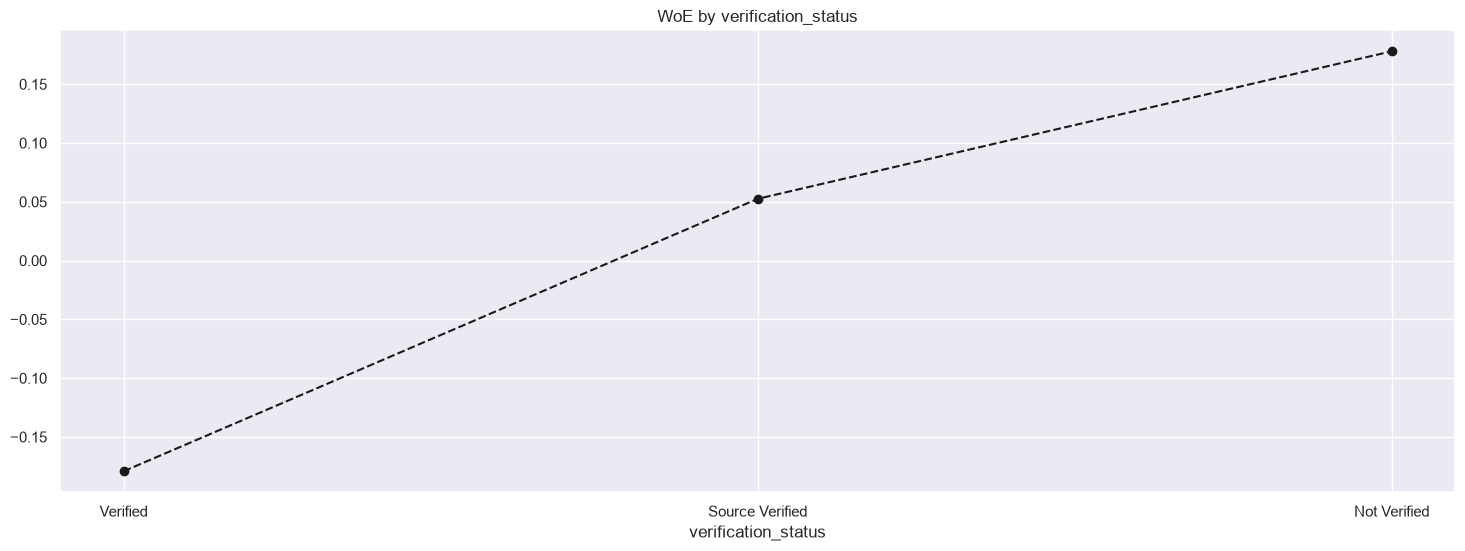

In [31]:
plot_by_woe(df_verif_sts)
# almost same n_obs, so use Verified as reference

In [32]:
# 5 initial list status
df_ini_sts = df_ini_sts.sort_values('WoE').reset_index(drop=True)
df_ini_sts
# based on WoE and n_obs, 'initial_status_w' as reference

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,f,60491,0.879685,0.648648,53213.0,7278.0,0.640603,0.71423,-0.108794,0.024888
1,w,32766,0.911127,0.351352,29854.0,2912.0,0.359397,0.28577,0.229238,0.024888


In [33]:
# 6 Purpose
df_purpose = woe_cal(df_input_prep, 'purpose', df_target_prep)
df_purpose = df_purpose.sort_values('WoE').reset_index(drop=True)
df_purpose

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,educational,89,0.752809,0.000954,67.0,22.0,0.000807,0.002159,-0.984590,0.045124
1,renewable_energy,70,0.771429,0.000751,54.0,16.0,0.000650,0.001570,-0.881845,0.045124
2,small_business,1431,0.777079,0.015345,1112.0,319.0,0.013387,0.031305,-0.849516,0.045124
3,medical,918,0.857298,0.009844,787.0,131.0,0.009474,0.012856,-0.305210,0.045124
4,house,439,0.858770,0.004707,377.0,62.0,0.004539,0.006084,-0.293130,0.045124
5,other,4806,0.861007,0.051535,4138.0,668.0,0.049815,0.065554,-0.274561,0.045124
6,wedding,456,0.864035,0.004890,394.0,62.0,0.004743,0.006084,-0.249024,0.045124
7,moving,602,0.878738,0.006455,529.0,73.0,0.006368,0.007164,-0.117712,0.045124
8,vacation,496,0.881048,0.005319,437.0,59.0,0.005261,0.005790,-0.095845,0.045124
9,debt_consolidation,55012,0.885916,0.589897,48736.0,6276.0,0.586707,0.615898,-0.048556,0.045124


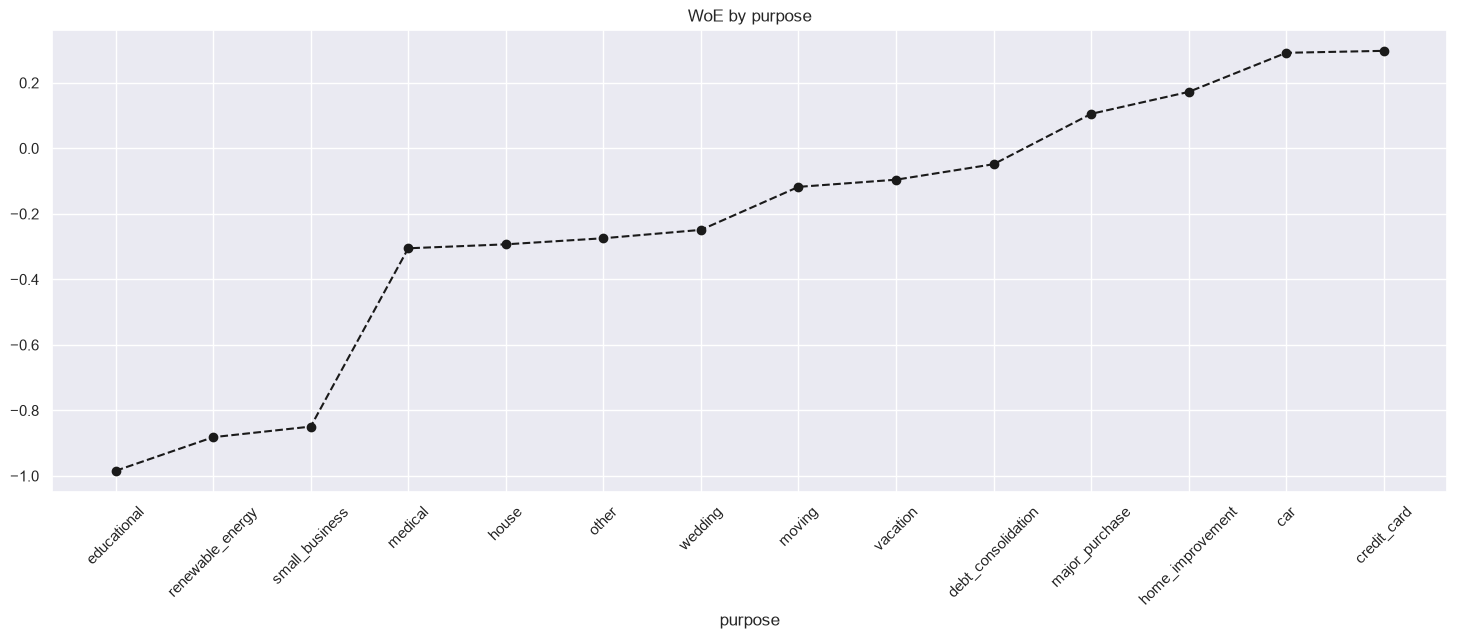

In [34]:
plot_by_woe(df_purpose, 45)

In [35]:
# debt_consolidation(219K), credit_card(83K), then home_improvement(21K),other(18K)
recategory = ['small_business+educational', 'moving+house+other+renewable_energy+medical', 
              'wedding+vacation','debt_consolidation','home_improvement+major_purchase+car','credit_card']
df_input_prep['purpose_sb_ed'] = df_input_prep[['purpose_small_business', 'purpose_educational']].sum(axis=1)
df_input_prep['purpose_other_mhrm'] = df_input_prep[['purpose_moving', 'purpose_house','purpose_other',
    'purpose_renewable_energy','purpose_medical']].sum(axis=1)
df_input_prep['purpose_wed_vac'] = df_input_prep[['purpose_wedding', 'purpose_vacation']].sum(axis=1)
df_input_prep['purpose_imp_maj+car'] = df_input_prep[['purpose_home_improvement','purpose_major_purchase','purpose_car']].sum(axis=1)

In [36]:
# Back to Course 
# Coutinous Numbers 

In [37]:
def woe_conti(df, disc_var_name, good_bad_var_df):
    df = pd.concat([df[disc_var_name],good_bad_var_df], axis=1)
    df = pd.concat([df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].count(), 
                      df.groupby(df.columns.values[0],as_index = False)[df.columns.values[1]].mean()],axis=1)
    df = df.iloc[:,[0,1,3]]
    df.columns = [df.columns.values[0],'n_obs','prop_good']
    df['prop_n_obs'] = df['n_obs']/df['n_obs'].sum()
    df['n_good'] = df['prop_good']*df['n_obs']
    df['n_bad'] = (1-df['prop_good'])*df['n_obs']
    df['prop_n_good'] = df['n_good']/df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad']/df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good']/df['prop_n_bad'])
    df['IV'] = ((df['prop_n_good']-df['prop_n_bad']) * df['WoE']).sum()
    return df

In [38]:
# 7 term length
df_input_prep['term_int'].unique()

<IntegerArray>
[60, 36]
Length: 2, dtype: Int64

In [39]:
df_term = woe_conti(df_input_prep, 'term_int', df_target_prep)
df_term

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,36,67534,0.902597,0.724171,60956.0,6578.0,0.733817,0.645535,0.128181,0.036603
1,60,25723,0.859581,0.275829,22111.0,3612.0,0.266183,0.354465,-0.286427,0.036603


In [40]:
df_input_prep['term_36'] = np.where((df_input_prep['term_int']==36),1,0)
df_input_prep['term_60'] = np.where((df_input_prep['term_int']==60),1,0)

In [41]:
# 8 employment length
df_emp_length= woe_conti(df_input_prep, 'emp_length_int', df_target_prep)
df_emp_length


,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,11553,0.874491,0.123883,10103.0,1450.0,0.121625,0.142296,-0.156972,0.007766
1,1.0,5968,0.892594,0.063995,5327.0,641.0,0.064129,0.062905,0.019273,0.007766
2,2.0,8295,0.887402,0.088948,7361.0,934.0,0.088615,0.091658,-0.033766,0.007766
3,3.0,7391,0.889325,0.079254,6573.0,818.0,0.079129,0.080275,-0.014377,0.007766
4,4.0,5555,0.889469,0.059567,4941.0,614.0,0.059482,0.060255,-0.012913,0.007766
5,5.0,6172,0.886261,0.066183,5470.0,702.0,0.065850,0.068891,-0.045140,0.007766
6,6.0,5225,0.878852,0.056028,4592.0,633.0,0.055281,0.062120,-0.116640,0.007766
7,7.0,5131,0.893588,0.055020,4585.0,546.0,0.055196,0.053582,0.029686,0.007766
8,8.0,4542,0.890137,0.048704,4043.0,499.0,0.048672,0.048970,-0.006104,0.007766
9,9.0,3621,0.892847,0.038828,3233.0,388.0,0.038920,0.038077,0.021920,0.007766


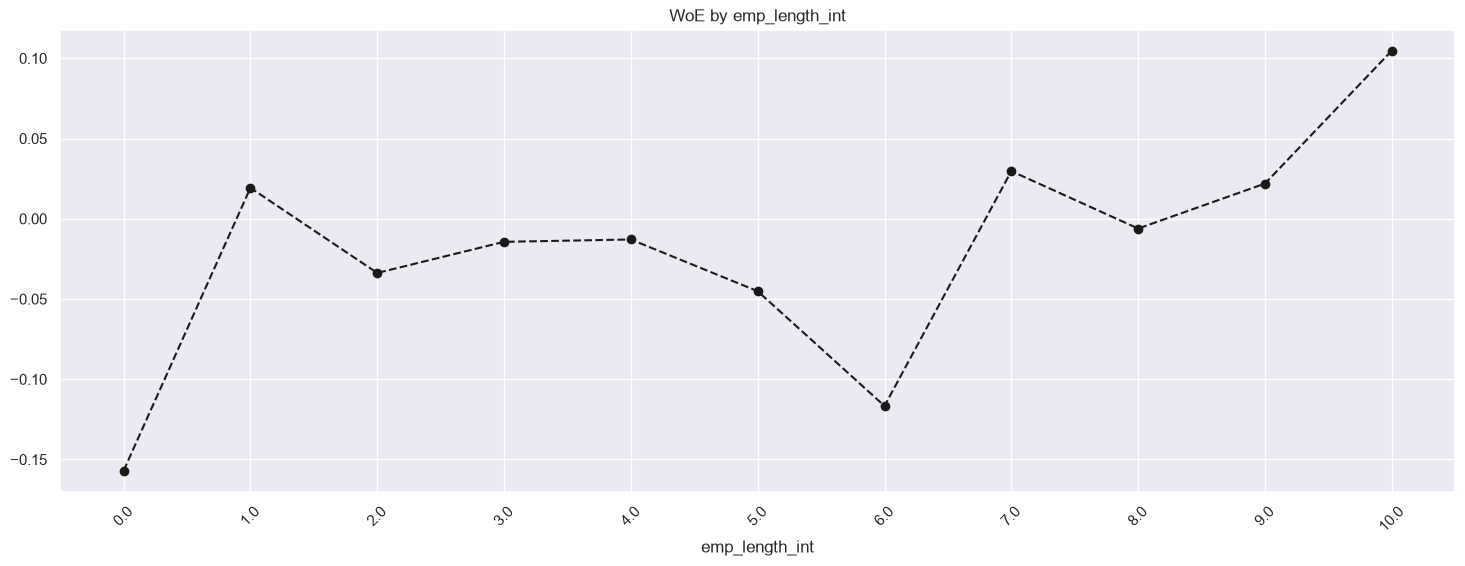

In [42]:
plot_by_woe(df_emp_length, 45)

In [43]:
df_input_prep['emp_length_0'] = np.where(df_input_prep['emp_length_int'].isin([0]),1,0)
df_input_prep['emp_length_1'] = np.where(df_input_prep['emp_length_int'].isin([1]),1,0)
df_input_prep['emp_length_2-4'] = np.where(df_input_prep['emp_length_int'].isin(range(2,5)),1,0)
df_input_prep['emp_length_5-6'] = np.where(df_input_prep['emp_length_int'].isin(range(5,7)),1,0)
df_input_prep['emp_length_7-9'] = np.where(df_input_prep['emp_length_int'].isin(range(7,10)),1,0)
df_input_prep['emp_length_10'] = np.where(df_input_prep['emp_length_int'].isin([10]),1,0)

In [44]:
# 9 month since issue date
df_input_prep['mths_since_issued'].unique()
# as there are around 90, cut into 50?  
# what about the smaller slices? as we have to regroup anayway? for example, cut into 30? 

array([ 41.,  38.,  66.,  37.,  58.,  50.,  86.,  51.,  48.,  59.,  72.,
        77.,  47.,  46.,  56.,  55., 119.,  63., 102.,  39.,  53.,  40.,
        52.,  43.,  49.,  57.,  45.,  36.,  54.,  74.,  44.,  73., 103.,
        70.,  95.,  89.,  68.,  82.,  71.,  76., 104.,  65.,  80.,  91.,
        75.,  67.,  42.,  61.,  64.,  60.,  85.,  88., 110.,  96.,  78.,
        83.,  69.,  90.,  62., 108.,  79.,  92., 118.,  99.,  81., 115.,
        97., 114., 116., 100.,  93., 117., 106., 124., 101., 125.,  87.,
        84.,  94., 105., 109.,  98., 107., 112., 113., 122., 111., 120.,
       121., 123., 126.])

In [45]:
# course cut into 50
df_input_prep['mths_since_issued_factor'] = pd.cut(df_input_prep['mths_since_issued'],50)
df_input_prep['mths_since_issued_factor']

362514     (39.6, 41.4]
288564     (37.8, 39.6]
213591     (64.8, 66.6]
263083    (35.91, 37.8]
165001     (57.6, 59.4]
              ...      
115        (70.2, 72.0]
296284     (37.8, 39.6]
61777      (48.6, 50.4]
91763      (50.4, 52.2]
167512     (57.6, 59.4]
Name: mths_since_issued_factor, Length: 93257, dtype: category
Categories (50, interval[float64, right]): [(35.91, 37.8] < (37.8, 39.6] < (39.6, 41.4] < (41.4, 43.2] ... (118.8, 120.6] < (120.6, 122.4] < (122.4, 124.2] < (124.2, 126.0]]

In [46]:
df_issued = woe_conti(df_input_prep, 'mths_since_issued_factor', df_target_prep)
df_issued

,mths_since_issued_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(35.91, 37.8]",7191,0.945766,0.077109,6801.0,390.0,0.081874,0.038273,0.760438,0.126297
1,"(37.8, 39.6]",9752,0.930373,0.104571,9073.0,679.0,0.109225,0.066634,0.494196,0.126297
2,"(39.6, 41.4]",9506,0.919945,0.101933,8745.0,761.0,0.105276,0.074681,0.343363,0.126297
3,"(41.4, 43.2]",7240,0.909116,0.077635,6582.0,658.0,0.079237,0.064573,0.204648,0.126297
4,"(43.2, 45.0]",7217,0.902868,0.077388,6516.0,701.0,0.078443,0.068793,0.131267,0.126297
5,"(45.0, 46.8]",3104,0.895296,0.033284,2779.0,325.0,0.033455,0.031894,0.047781,0.126297
6,"(46.8, 48.6]",6197,0.890269,0.066451,5517.0,680.0,0.066416,0.066732,-0.004744,0.126297
7,"(48.6, 50.4]",5821,0.885930,0.062419,5157.0,664.0,0.062082,0.065162,-0.048413,0.126297
8,"(50.4, 52.2]",5021,0.878909,0.053840,4413.0,608.0,0.053126,0.059666,-0.116106,0.126297
9,"(52.2, 54.0]",4497,0.874138,0.048222,3931.0,566.0,0.047323,0.055545,-0.160186,0.126297


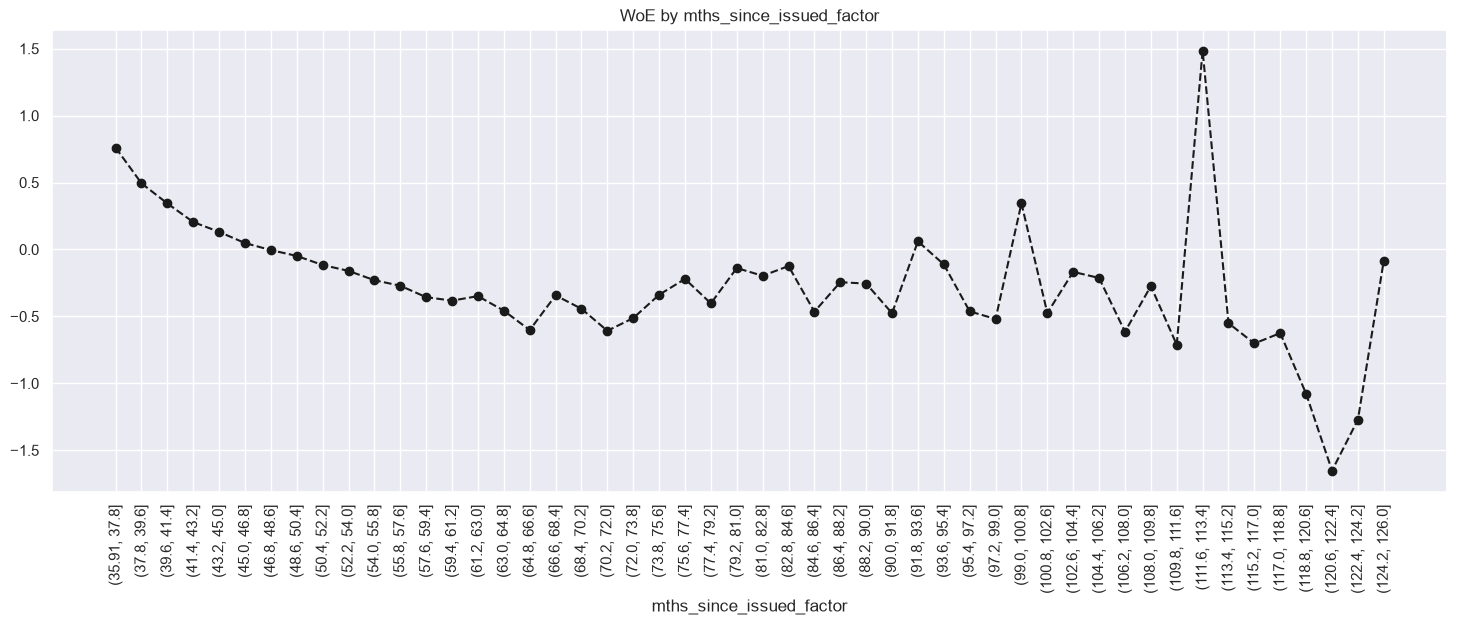

In [47]:
plot_by_woe(df_issued, 90)

In [48]:
# self test on cut into 30
df_input_prep['mths_since_issued_fac_test'] = pd.cut(df_input_prep['mths_since_issued'],30)
df_issued_test = woe_conti(df_input_prep, 'mths_since_issued_fac_test', df_target_prep)
df_issued_test
# slices could be <39, 39-42, 42-48, 48-51 ....
# 30 missed the 38 point, might be too small slices

,mths_since_issued_fac_test,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(35.91, 39.0]",16943,0.936906,0.181681,15874.0,1069.0,0.191099,0.104907,0.599718,0.120783
1,"(39.0, 42.0]",12904,0.916847,0.138370,11831.0,1073.0,0.142427,0.105299,0.302024,0.120783
2,"(42.0, 45.0]",11059,0.905326,0.118586,10012.0,1047.0,0.120529,0.102748,0.159615,0.120783
3,"(45.0, 48.0]",9301,0.891947,0.099735,8296.0,1005.0,0.099871,0.098626,0.012545,0.120783
4,"(48.0, 51.0]",8433,0.885450,0.090428,7467.0,966.0,0.089891,0.094799,-0.053156,0.120783
5,"(51.0, 54.0]",6906,0.873733,0.074053,6034.0,872.0,0.072640,0.085574,-0.163865,0.120783
6,"(54.0, 57.0]",5636,0.863201,0.060435,4865.0,771.0,0.058567,0.075662,-0.256107,0.120783
7,"(57.0, 60.0]",4101,0.850280,0.043975,3487.0,614.0,0.041978,0.060255,-0.361439,0.120783
8,"(60.0, 63.0]",3816,0.850105,0.040919,3244.0,572.0,0.039053,0.056133,-0.362817,0.120783
9,"(63.0, 66.0]",2836,0.825106,0.030411,2340.0,496.0,0.028170,0.048675,-0.546910,0.120783


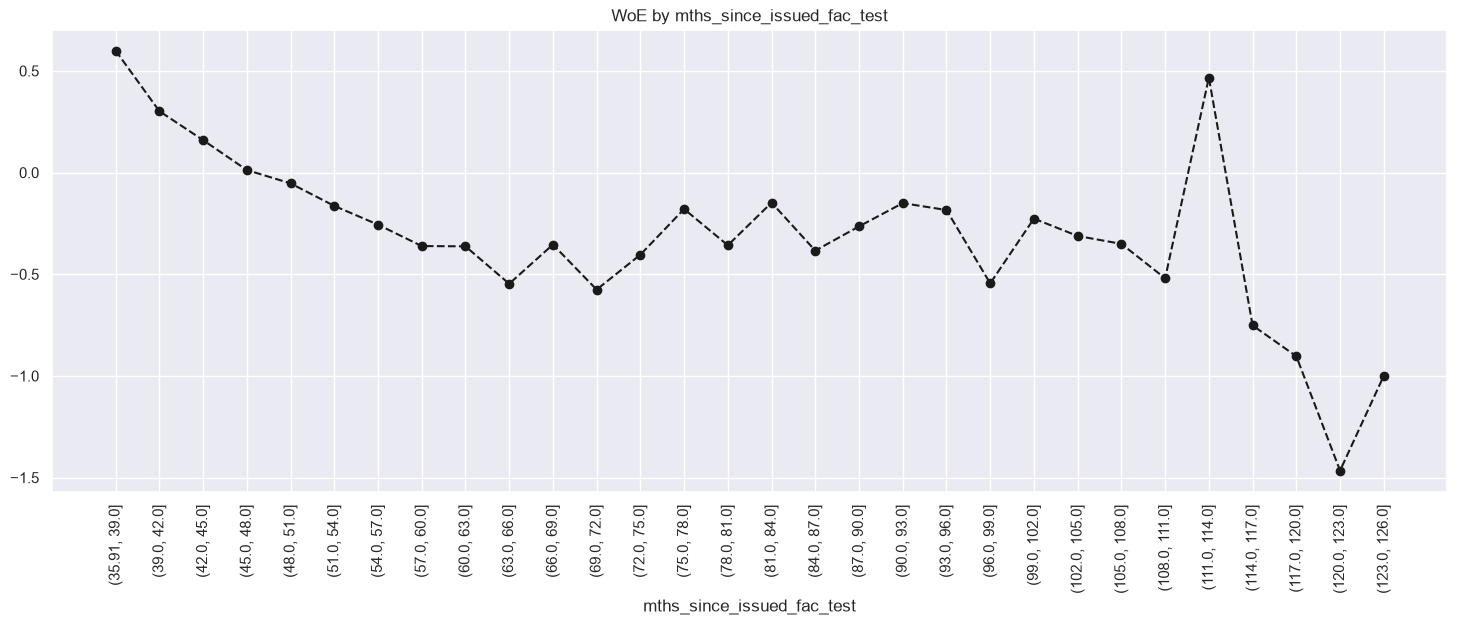

In [49]:
plot_by_woe(df_issued_test, 90)

In [50]:
# self test on cut into 40 
df_input_prep['mths_since_issued_fac_test'] = pd.cut(df_input_prep['mths_since_issued'],40)
df_issued_test = woe_conti(df_input_prep, 'mths_since_issued_fac_test', df_target_prep)
df_issued_test
# similar, might also work

,mths_since_issued_fac_test,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(35.91, 38.25]",14891,0.938285,0.159677,13972.0,919.0,0.168202,0.090186,0.623284,0.122133
1,"(38.25, 40.5]",5770,0.924957,0.061872,5337.0,433.0,0.064249,0.042493,0.413441,0.122133
2,"(40.5, 42.75]",9186,0.914000,0.098502,8396.0,790.0,0.101075,0.077527,0.265237,0.122133
3,"(42.75, 45.0]",11059,0.905326,0.118586,10012.0,1047.0,0.120529,0.102748,0.159615,0.122133
4,"(45.0, 47.25]",6250,0.891840,0.067019,5574.0,676.0,0.067102,0.066340,0.011434,0.122133
5,"(47.25, 49.5]",5973,0.889335,0.064049,5312.0,661.0,0.063948,0.064868,-0.014271,0.122133
6,"(49.5, 51.75]",5511,0.884957,0.059095,4877.0,634.0,0.058712,0.062218,-0.058004,0.122133
7,"(51.75, 54.0]",6906,0.873733,0.074053,6034.0,872.0,0.072640,0.085574,-0.163865,0.122133
8,"(54.0, 56.25]",4002,0.860820,0.042914,3445.0,557.0,0.041473,0.054661,-0.276127,0.122133
9,"(56.25, 58.5]",3145,0.864229,0.033724,2718.0,427.0,0.032721,0.041904,-0.247373,0.122133


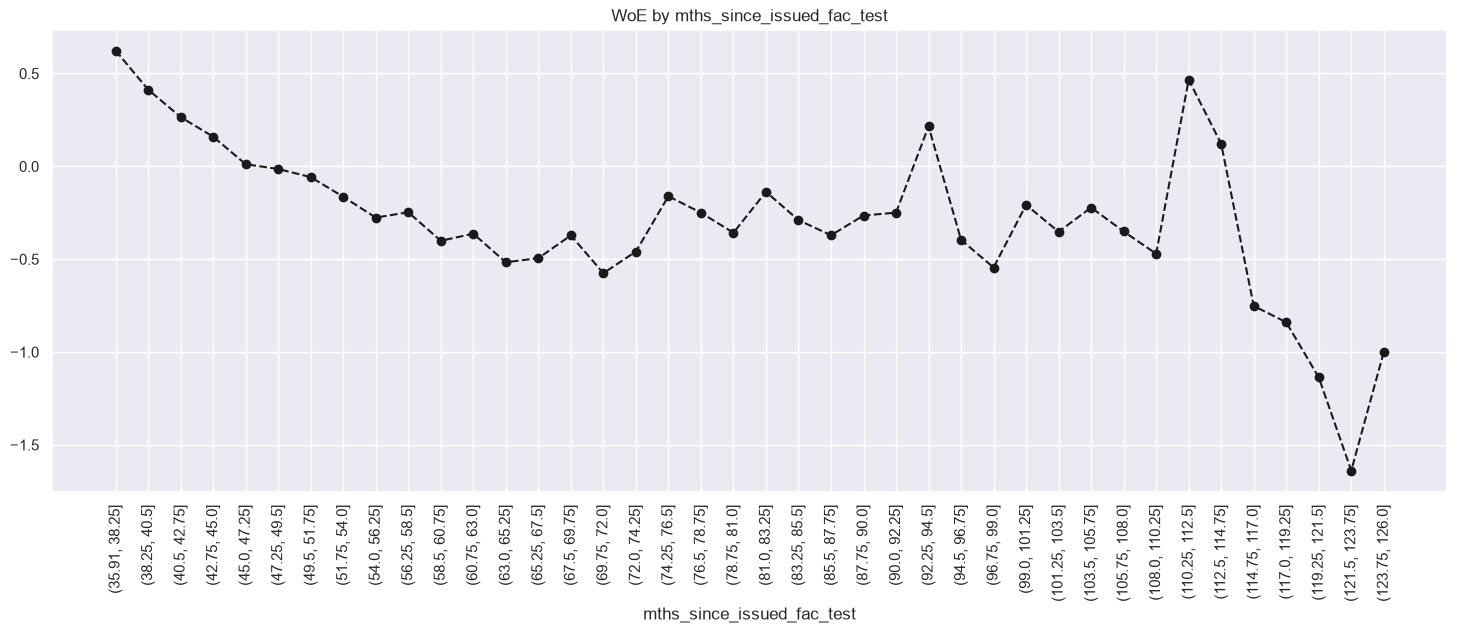

In [51]:
plot_by_woe(df_issued_test, 90)

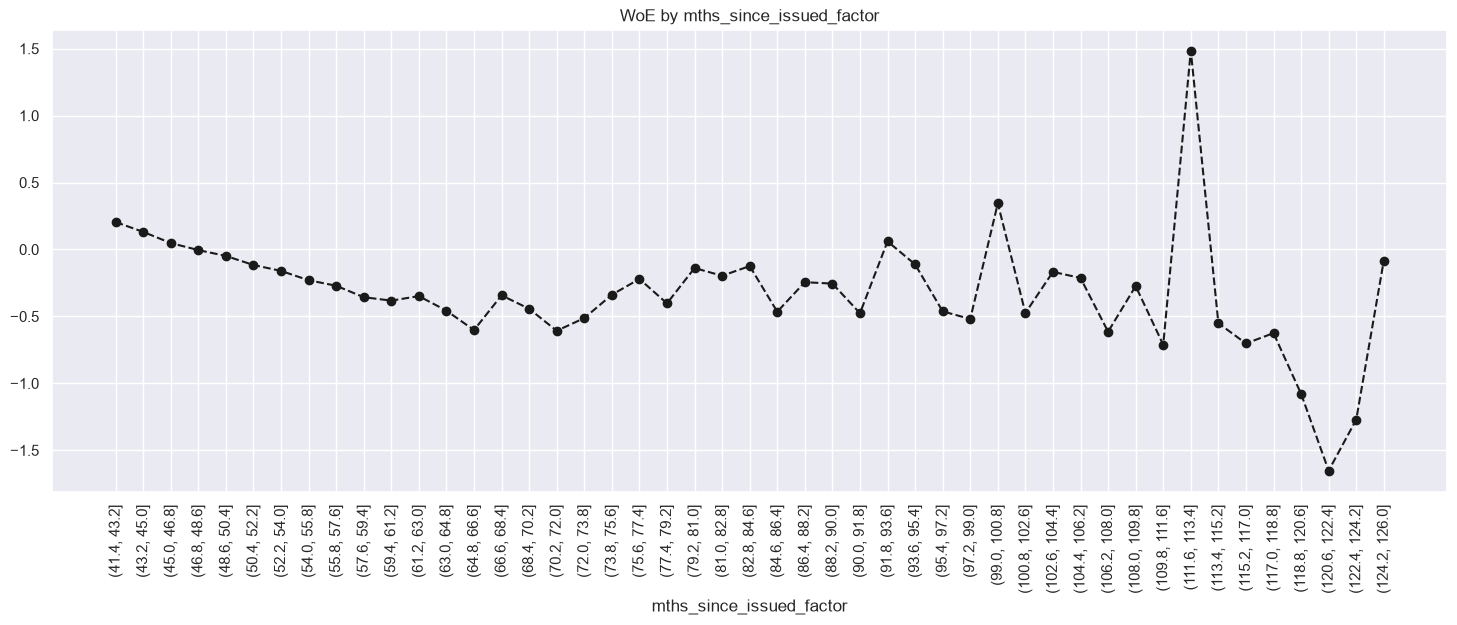

In [52]:
# follow the program first, testing can be used later for my own verification 
plot_by_woe(df_issued.iloc[3: , :],90)

In [53]:
df_input_prep['mths_since_issued_<38'] = np.where(df_input_prep['mths_since_issued'].isin(range(38)),1,0)
df_input_prep['mths_since_issued_38-39'] = np.where(df_input_prep['mths_since_issued'].isin(range(38,40)),1,0)
df_input_prep['mths_since_issued_40-41'] = np.where(df_input_prep['mths_since_issued'].isin(range(40,42)),1,0)
df_input_prep['mths_since_issued_42-48'] = np.where(df_input_prep['mths_since_issued'].isin(range(42,49)),1,0)
df_input_prep['mths_since_issued_49-52'] = np.where(df_input_prep['mths_since_issued'].isin(range(49,53)),1,0)
df_input_prep['mths_since_issued_53-64'] = np.where(df_input_prep['mths_since_issued'].isin(range(53,65)),1,0)
df_input_prep['mths_since_issued_65-84'] = np.where(df_input_prep['mths_since_issued'].isin(range(65,85)),1,0)
df_input_prep['mths_since_issued_>84'] = np.where(df_input_prep['mths_since_issued'].isin(range(85,int(df_input_prep['mths_since_issued'].max()))),1,0)

In [54]:
# 10. interest rate 
df_input_prep['int_factor'] = pd.cut(df_input_prep['int_rate'],50)
df_int = woe_conti(df_input_prep, 'int_factor', df_target_prep)
df_int

,int_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(5.399, 5.833]",198,0.969697,0.002123,192.0,6.0,0.002311,0.000589,1.367495,0.371465
1,"(5.833, 6.246]",2086,0.979866,0.022368,2044.0,42.0,0.024607,0.004122,1.786754,0.371465
2,"(6.246, 6.658]",1974,0.972138,0.021167,1919.0,55.0,0.023102,0.005397,1.453986,0.371465
3,"(6.658, 7.071]",477,0.951782,0.005115,454.0,23.0,0.005465,0.002257,0.884362,0.371465
4,"(7.071, 7.484]",804,0.981343,0.008621,789.0,15.0,0.009498,0.001472,1.864475,0.371465
5,"(7.484, 7.897]",3245,0.965485,0.034796,3133.0,112.0,0.037717,0.010991,1.233007,0.371465
6,"(7.897, 8.31]",2429,0.951009,0.026046,2310.0,119.0,0.027809,0.011678,0.867639,0.371465
7,"(8.31, 8.722]",1680,0.965476,0.018015,1622.0,58.0,0.019526,0.005692,1.232732,0.371465
8,"(8.722, 9.135]",2384,0.942114,0.025564,2246.0,138.0,0.027038,0.013543,0.691412,0.371465
9,"(9.135, 9.548]",1590,0.976730,0.017050,1553.0,37.0,0.018696,0.003631,1.638785,0.371465


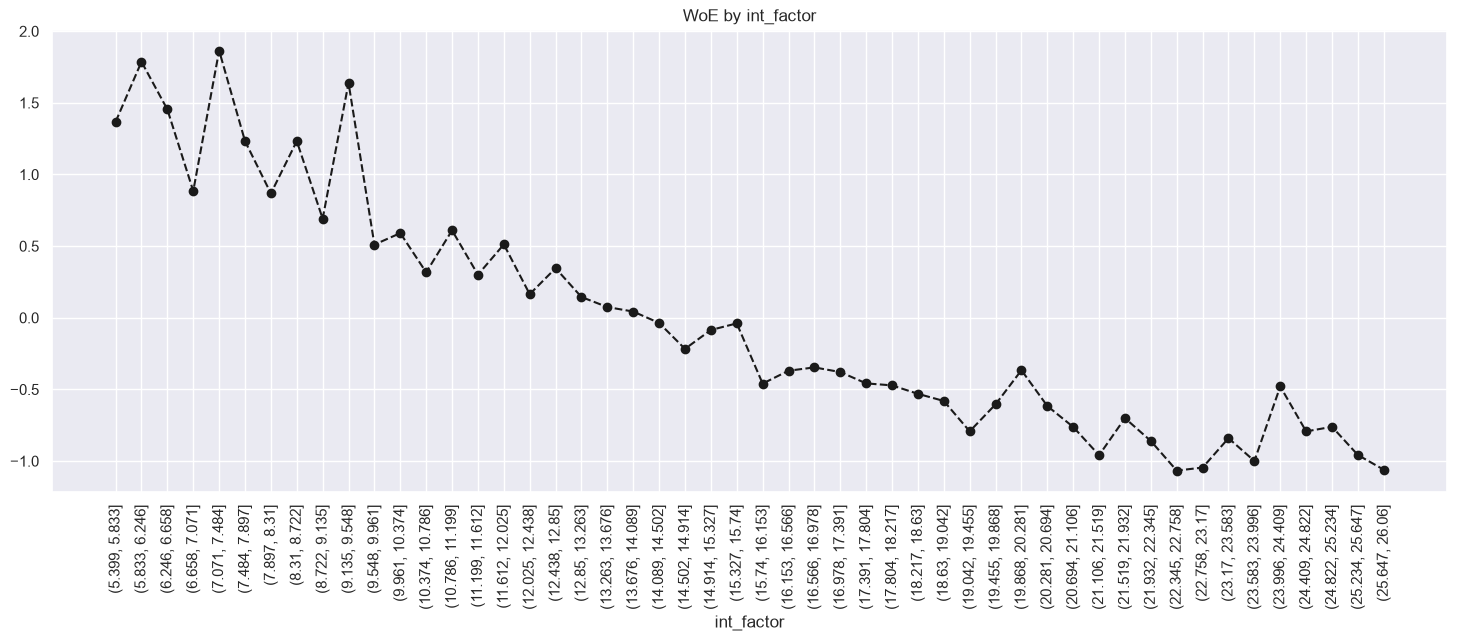

In [55]:
plot_by_woe(df_int, 90)

In [56]:
df_input_prep['int_rate_<9.548'] = np.where((df_input_prep['int_rate']<=9.548),1,0)
df_input_prep['int_rate_9.548-12.025'] = np.where((df_input_prep['int_rate']>9.548)&(df_input_prep['int_rate']<=12.025),1,0)
df_input_prep['int_rate_12.025-15.74'] = np.where((df_input_prep['int_rate']>12.025)&(df_input_prep['int_rate']<=15.74),1,0)
df_input_prep['int_rate_15.74-20.281'] = np.where((df_input_prep['int_rate']>15.74)&(df_input_prep['int_rate']<=20.281),1,0)
df_input_prep['int_rate_>20.281'] = np.where((df_input_prep['int_rate']>20.281),1,0)

In [57]:
# 11. Funded amount
df_input_prep['fund_amt_factor'] = pd.cut(df_input_prep['funded_amnt'],50)
df_fundamt = woe_conti(df_input_prep, 'fund_amt_factor', df_target_prep)
df_fundamt

,fund_amt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(465.5, 1190.0]",319,0.880878,0.003421,281.0,38.0,0.003383,0.003729,-0.097472,0.018663
1,"(1190.0, 1880.0]",800,0.896250,0.008578,717.0,83.0,0.008632,0.008145,0.057995,0.018663
2,"(1880.0, 2570.0]",1513,0.900198,0.016224,1362.0,151.0,0.016396,0.014818,0.101189,0.018663
3,"(2570.0, 3260.0]",1817,0.893781,0.019484,1624.0,193.0,0.019550,0.018940,0.031717,0.018663
4,"(3260.0, 3950.0]",1245,0.891566,0.013350,1110.0,135.0,0.013363,0.013248,0.008600,0.018663
5,"(3950.0, 4640.0]",2298,0.882942,0.024642,2029.0,269.0,0.024426,0.026398,-0.077654,0.018663
6,"(4640.0, 5330.0]",3957,0.898155,0.042431,3554.0,403.0,0.042785,0.039549,0.078652,0.018663
7,"(5330.0, 6020.0]",4186,0.906593,0.044887,3795.0,391.0,0.045686,0.038371,0.174491,0.018663
8,"(6020.0, 6710.0]",1718,0.881839,0.018422,1515.0,203.0,0.018238,0.019921,-0.088276,0.018663
9,"(6710.0, 7400.0]",2880,0.893403,0.030882,2573.0,307.0,0.030975,0.030128,0.027739,0.018663


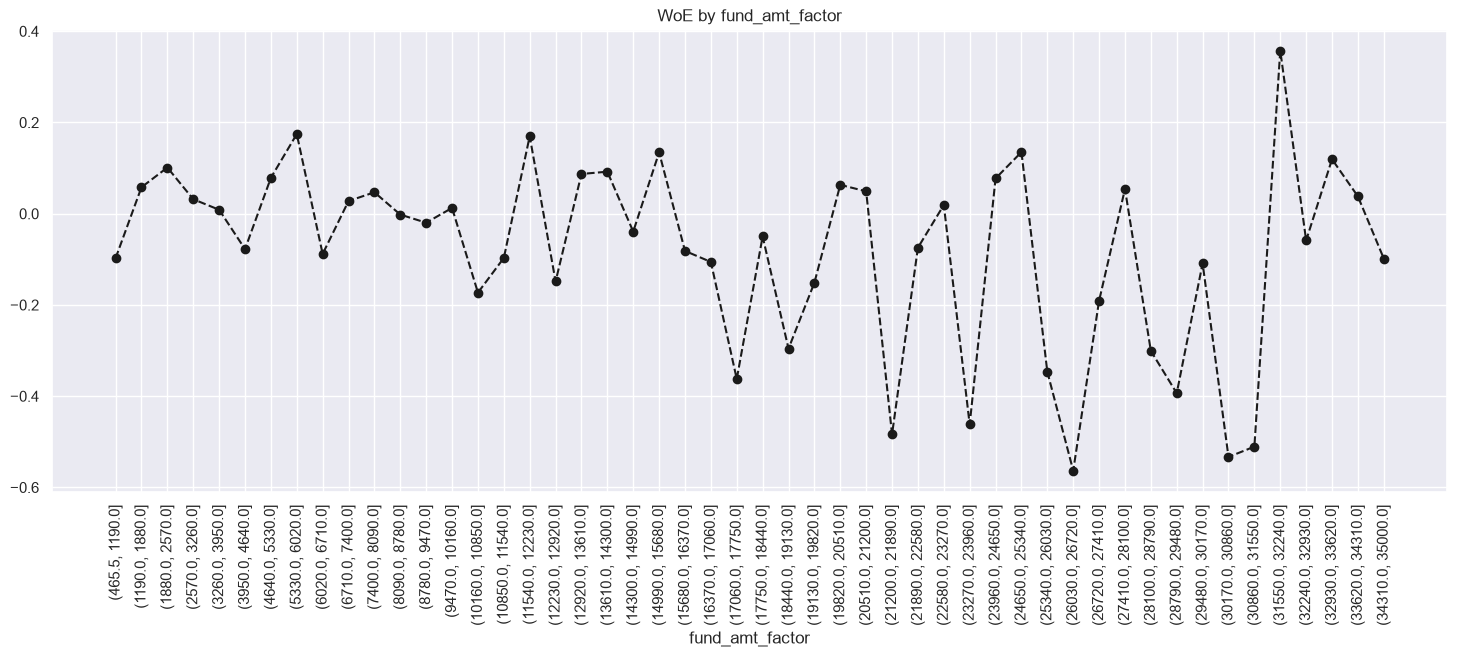

In [58]:
plot_by_woe(df_fundamt, 90)
# due to this great variation, this can not be used for PD model, as it can't be defined as dummies
# no fine classing

In [59]:
# HOMEWORK
# 11. Months since early crline
# check unique number first
df_input_prep['mths_since_earlist_crline'].unique()

array([188., 172., 189., 112., 374., 207., 332., 266., 383., 269., 328.,
       237., 293., 242., 228., 287., 231., 206., 263., 167., 239., 134.,
       441., 195., 127., 286., 192., 518., 170., 147., 150., 252., 202.,
       197., 190., 300., 233., 220., 416., 225., 217., 200., 209., 587.,
       194., 262., 156., 227., 391., 141., 183., 302., 267., 312., 362.,
       216., 438., 249., 273., 182., 221., 187., 567., 245., 205., 347.,
       214., 299., 176., 397., 386., 253., 243., 398., 153., 466., 198.,
       229., 241., 180., 389., 181., 169., 261., 378., 324., 400., 232.,
       486., 123., 350., 549., 139., 244., 255., 126., 219., 175., 115.,
       413., 173., 210., 274., 354., 254., 327., 321., 323., 201., 171.,
       280., 443., 329., 294., 257., 223., 258., 259., 158., 348., 162.,
       168., 303., 313., 298., 320.,  91., 439., 174., 520., 251., 317.,
       144., 204., 246., 406., 119., 304., 279., 379., 230., 160., 305.,
        79., 196., 306., 333., 331., 256., 113., 34

In [60]:
# found less than 50 slices, so investigate why? 
bins = pd.cut(df_input_prep['mths_since_earlist_crline'],50)
bins.value_counts().sort_index()
# since there are some bins counts as 0, we could just use the countinous number in the chart

mths_since_earlist_crline
(-0.587, 11.74]        5
(11.74, 23.48]         0
(23.48, 35.22]         0
(35.22, 46.96]         0
(46.96, 58.7]          0
(58.7, 70.44]          0
(70.44, 82.18]       182
(82.18, 93.92]       508
(93.92, 105.66]      715
(105.66, 117.4]     1268
(117.4, 129.14]     2314
(129.14, 140.88]    2816
(140.88, 152.62]    3366
(152.62, 164.36]    3989
(164.36, 176.1]     4857
(176.1, 187.84]     5076
(187.84, 199.58]    6578
(199.58, 211.32]    7131
(211.32, 223.06]    6775
(223.06, 234.8]     5521
(234.8, 246.54]     4966
(246.54, 258.28]    4549
(258.28, 270.02]    4472
(270.02, 281.76]    3672
(281.76, 293.5]     3640
(293.5, 305.24]     2602
(305.24, 316.98]    1988
(316.98, 328.72]    2020
(328.72, 340.46]    2129
(340.46, 352.2]     1810
(352.2, 363.94]     1477
(363.94, 375.68]    1360
(375.68, 387.42]    1152
(387.42, 399.16]    1051
(399.16, 410.9]      826
(410.9, 422.64]      808
(422.64, 434.38]     524
(434.38, 446.12]     416
(446.12, 457.86]     329

In [61]:
df_input_prep['mths_crline_factor'] = pd.cut(df_input_prep['mths_since_earlist_crline'],50)
df_crline = woe_conti(df_input_prep, 'mths_crline_factor', df_target_prep)
df_crline

,mths_crline_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.587, 11.74]",5,1.000000,0.000054,5.0,0.0,0.000060,0.000000,inf,inf
1,"(70.44, 82.18]",182,0.923077,0.001952,168.0,14.0,0.002022,0.001374,0.386666,inf
2,"(82.18, 93.92]",508,0.913386,0.005447,464.0,44.0,0.005586,0.004318,0.257454,inf
3,"(93.92, 105.66]",715,0.851748,0.007667,609.0,106.0,0.007331,0.010402,-0.349861,inf
4,"(105.66, 117.4]",1268,0.854890,0.013597,1084.0,184.0,0.013050,0.018057,-0.324763,inf
5,"(117.4, 129.14]",2314,0.875108,0.024813,2025.0,289.0,0.024378,0.028361,-0.151342,inf
6,"(129.14, 140.88]",2816,0.860795,0.030196,2424.0,392.0,0.029181,0.038469,-0.276328,inf
7,"(140.88, 152.62]",3366,0.882353,0.036094,2970.0,396.0,0.035754,0.038862,-0.083338,inf
8,"(152.62, 164.36]",3989,0.885686,0.042774,3533.0,456.0,0.042532,0.044750,-0.050831,inf
9,"(164.36, 176.1]",4857,0.886967,0.052082,4308.0,549.0,0.051862,0.053876,-0.038110,inf


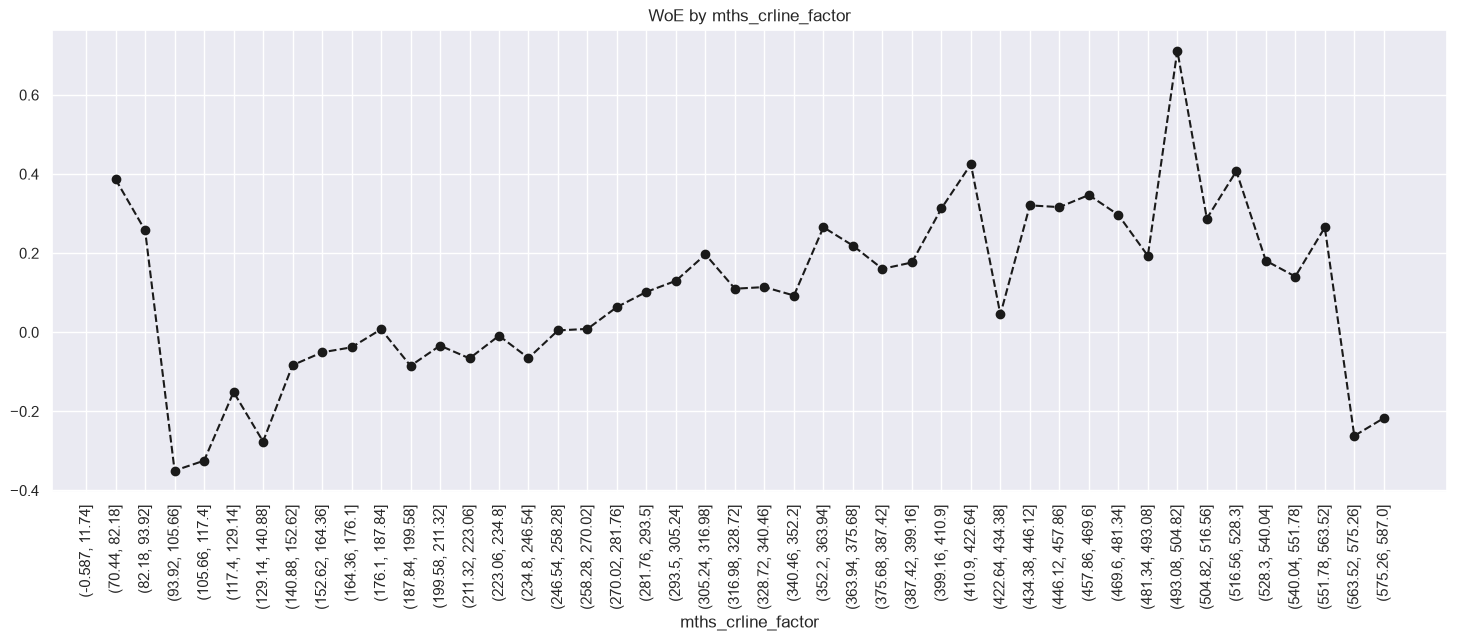

In [62]:
plot_by_woe(df_crline, 90)

In [63]:
# the first 6 fluncuate a lot, but obs number small, group up them; 
# <140.88, 140.88 - 164.36, 164.36-246.54, 246.54-270.02, 270.02-352.2, above with low number of obs and very flunctuate
df_input_prep['mths_since_earlist_crline_<140'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(140)), 1, 0)
df_input_prep['mths_since_earlist_crline_140-164'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(140, 165)), 1, 0)
df_input_prep['mths_since_earlist_crline_165-247'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(165, 248)), 1, 0)
df_input_prep['mths_since_earlist_crline_248-270'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(248, 271)), 1, 0)
df_input_prep['mths_since_earlist_crline_271-352'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(271, 353)), 1, 0)
df_input_prep['mths_since_earlist_crline_>352'] = np.where(df_input_prep['mths_since_earlist_crline'].isin(range(353, int(df_input_prep['mths_since_earlist_crline'].max()))), 1, 0)

In [64]:
# check the number of unique varaiables first to see what approach 
a=df_input_prep['installment'].unique() # ~many
b=df_input_prep['delinq_2yrs'].unique()# 20
c=df_input_prep['open_acc'].unique() #60
d=df_input_prep['pub_rec'].unique() # 20
e=df_input_prep['total_acc'].unique() # ~160
f=df_input_prep['acc_now_delinq'].unique() #5
print(a)
print(b)
print(c)
print(d)
print(e)
print(f)
# thus b, c, d, f, can use the variable directly, where the other two need cuts

[ 773.01  297.53 1034.83 ...  414.23  494.33  121.42]
[ 0.  1.  2.  3.  4.  6.  5.  7. 16.  8. 18. 10.  9. 13. 11. 14. 12. 19.
 15.]
[ 7. 18.  9. 12.  5. 22.  3. 17. 16.  6. 10. 20. 23. 13.  4. 15. 14. 11.
 19. 24. 21.  8. 31. 26.  1. 32. 37. 27. 25.  2. 28. 29. 30. 39. 34. 33.
 35. 36. 40.  0. 38. 53. 48. 52. 46. 42. 45. 43. 58. 41. 49. 61. 50.]
[ 0.  1.  2.  4.  3.  5. 12. 49.  7.  6.  8. 14. 11. 10.  9.]
[ 20.  43.  38.  31.  36.  48.  10.  45.   5.  32.  26.  41.  40.  47.
   8.  14.  42.  24.   6.  23.  17.  11.  25.  21.  28.  29.  12.  37.
  19.  35.  34.  30.  18.  13.   9.  44.  50.  22.  33.  59.  16.  15.
  27.  39.  46.  63.   7.  52.  56.  54.  49.   4.  57.  60.  53.  67.
  51.  55.  65.  61. 156.   3.  66.  58.  80.  64.  62.  73.  71.  72.
  91.  79.  69.   2.  78.   0.  81.  92.  74.  70.  77.  75.  68.  76.
  85.  88.  94.  97.   1.  99.  86.  89.  84.  83.  82.  93.]
[0. 1. 2. 3.]


In [65]:
# 12. Delinque for 2 years
df_delinq2yr = woe_conti(df_input_prep, 'delinq_2yrs', df_target_prep)
df_delinq2yr

,delinq_2yrs,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,76566,0.890944,0.821021,68216.0,8350.0,0.821217,0.819431,0.002177,inf
1,1.0,11297,0.890413,0.121138,10059.0,1238.0,0.121095,0.121492,-0.003270,inf
2,2.0,3192,0.885025,0.034228,2825.0,367.0,0.034009,0.036016,-0.057339,inf
3,3.0,1134,0.893298,0.012160,1013.0,121.0,0.012195,0.011874,0.026640,inf
4,4.0,510,0.886275,0.005469,452.0,58.0,0.005441,0.005692,-0.045001,inf
5,5.0,270,0.911111,0.002895,246.0,24.0,0.002961,0.002355,0.229037,inf
6,6.0,128,0.859375,0.001373,110.0,18.0,0.001324,0.001766,-0.288132,inf
7,7.0,67,0.925373,0.000718,62.0,5.0,0.000746,0.000491,0.419456,inf
8,8.0,29,0.896552,0.000311,26.0,3.0,0.000313,0.000294,0.061244,inf
9,9.0,22,0.954545,0.000236,21.0,1.0,0.000253,0.000098,0.946282,inf


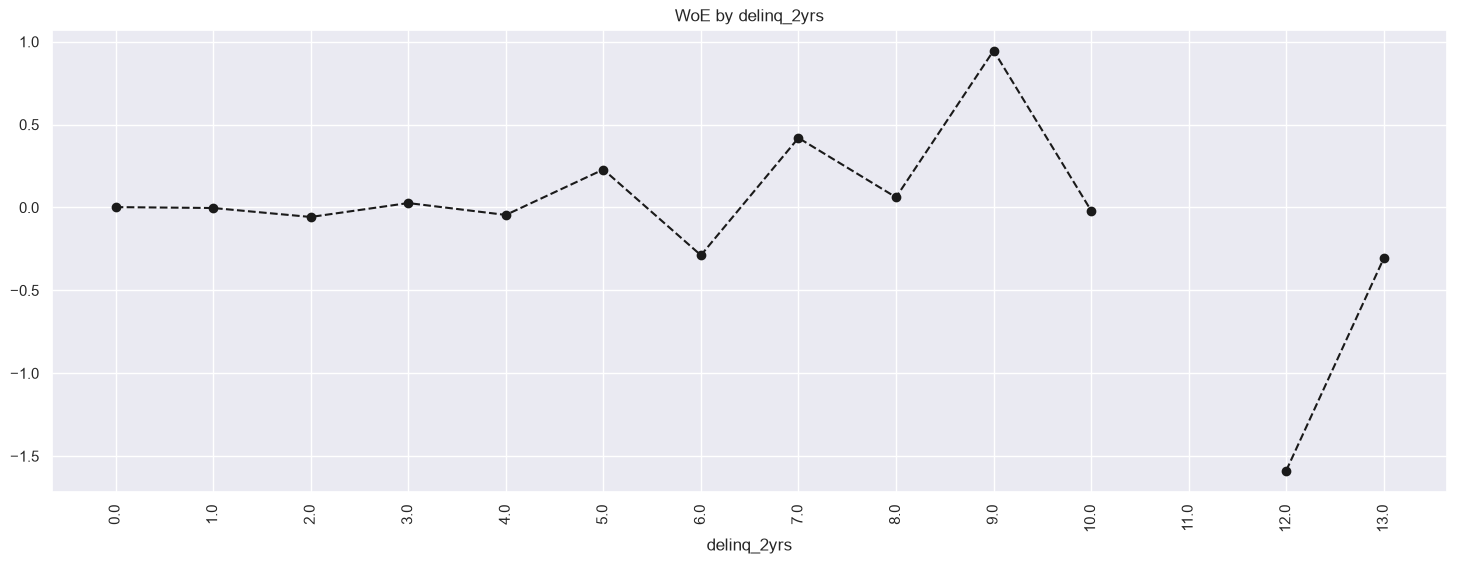

In [66]:
plot_by_woe(df_delinq2yr, 90)

In [67]:
# 0 on its own, 1-3, then >=4
df_input_prep['delinq_2yrs_0'] = np.where((df_input_prep['delinq_2yrs'] == 0), 1, 0)
df_input_prep['delinq_2yrs_1-3'] = np.where((df_input_prep['delinq_2yrs'] >= 1) & (df_input_prep['delinq_2yrs'] <= 3), 1, 0)
df_input_prep['delinq_2yrs_>=4'] = np.where((df_input_prep['delinq_2yrs'] >= 9), 1, 0)

In [68]:
# 13. Open Accout
df_openacc = woe_conti(df_input_prep, 'open_acc', df_target_prep)
df_openacc

,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,7,1.000000,0.000075,7.0,0.0,0.000084,0.000000,inf,inf
1,1.0,32,0.875000,0.000343,28.0,4.0,0.000337,0.000393,-0.152331,inf
2,2.0,334,0.838323,0.003582,280.0,54.0,0.003371,0.005299,-0.452435,inf
3,3.0,1122,0.852941,0.012031,957.0,165.0,0.011521,0.016192,-0.340383,inf
4,4.0,2560,0.892188,0.027451,2284.0,276.0,0.027496,0.027085,0.015042,inf
5,5.0,4403,0.891438,0.047214,3925.0,478.0,0.047251,0.046909,0.007270,inf
6,6.0,6216,0.890766,0.066655,5537.0,679.0,0.066657,0.066634,0.000346,inf
7,7.0,7433,0.886856,0.079704,6592.0,841.0,0.079358,0.082532,-0.039220,inf
8,8.0,8314,0.893433,0.089151,7428.0,886.0,0.089422,0.086948,0.028054,inf
9,9.0,8768,0.888230,0.094020,7788.0,980.0,0.093756,0.096173,-0.025454,inf


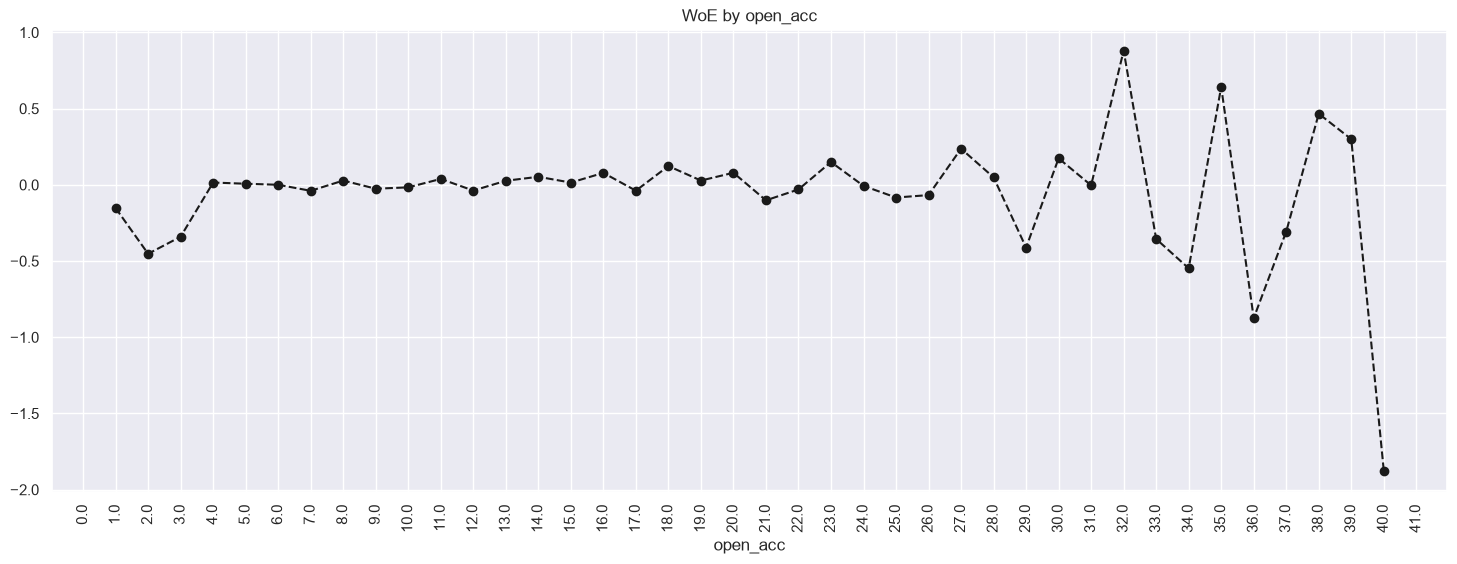

In [69]:
plot_by_woe(df_openacc, 90)

In [70]:
# groups:
df_input_prep['open_acc_0'] = np.where((df_input_prep['open_acc'] == 0), 1, 0)
df_input_prep['open_acc_1-3'] = np.where((df_input_prep['open_acc'] >= 1) &(df_input_prep['open_acc'] <= 3), 1, 0)
df_input_prep['open_acc_4-12'] = np.where((df_input_prep['open_acc'] >= 4) &(df_input_prep['open_acc'] <= 12), 1, 0)
df_input_prep['open_acc_13-17'] = np.where((df_input_prep['open_acc'] >= 13) & (df_input_prep['open_acc'] <= 17), 1, 0)
df_input_prep['open_acc_18-22'] = np.where((df_input_prep['open_acc'] >= 18) & (df_input_prep['open_acc'] <= 22), 1, 0)
df_input_prep['open_acc_23-25'] = np.where((df_input_prep['open_acc'] >= 23) & (df_input_prep['open_acc'] <= 25), 1, 0)
df_input_prep['open_acc_26-30'] = np.where((df_input_prep['open_acc'] >= 26) & (df_input_prep['open_acc'] <= 30), 1, 0)

df_input_prep['open_acc_>=31'] = np.where(
    df_input_prep['open_acc'] >= 31, 1, 0
)

In [71]:
# 14 pub_rec
df_pubrec = woe_conti(df_input_prep, 'pub_rec', df_target_prep)
df_pubrec
# most observations are in 0 and 1, 2 and above rearly has any

,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,80923,0.889179,0.867742,71955.0,8968.0,0.866228,0.880079,-0.015862,inf
1,1.0,10670,0.901125,0.114415,9615.0,1055.0,0.115750,0.103533,0.111543,inf
2,2.0,1097,0.904284,0.011763,992.0,105.0,0.011942,0.010304,0.147522,inf
3,3.0,331,0.900302,0.003549,298.0,33.0,0.003587,0.003238,0.102345,inf
4,4.0,112,0.857143,0.001201,96.0,16.0,0.001156,0.001570,-0.306481,inf
5,5.0,73,0.904110,0.000783,66.0,7.0,0.000795,0.000687,0.145504,inf
6,6.0,19,0.894737,0.000204,17.0,2.0,0.000205,0.000196,0.041825,inf
7,7.0,14,0.785714,0.000150,11.0,3.0,0.000132,0.000294,-0.798958,inf
8,8.0,5,0.800000,0.000054,4.0,1.0,0.000048,0.000098,-0.711946,inf
9,9.0,2,1.000000,0.000021,2.0,0.0,0.000024,0.000000,inf,inf


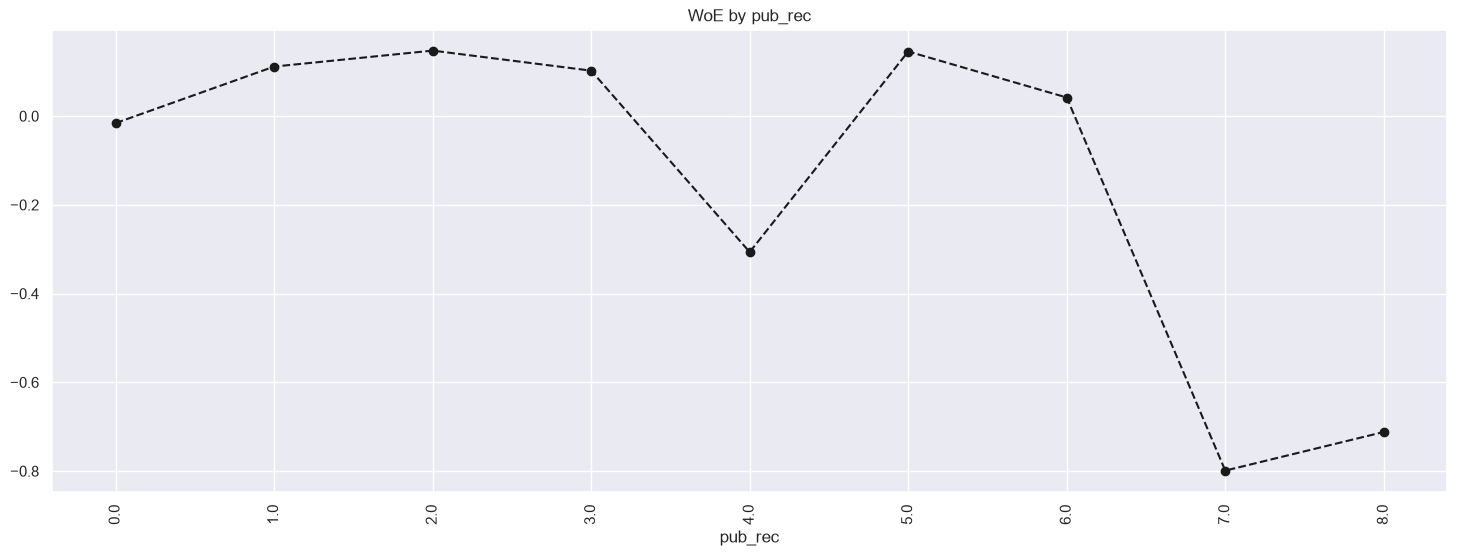

In [72]:
plot_by_woe(df_pubrec, 90)

In [73]:
df_input_prep['pub_rec_=0'] = np.where((df_input_prep['pub_rec']==0),1,0)
df_input_prep['pub_rec_1-2'] = np.where((df_input_prep['pub_rec'] >= 1) & (df_input_prep['pub_rec'] <= 2), 1, 0)
df_input_prep['pub_rec_3-4'] = np.where((df_input_prep['pub_rec'] >= 3) & (df_input_prep['pub_rec'] <= 4), 1, 0)
df_input_prep['pub_rec_>=5'] = np.where((df_input_prep['pub_rec'] >= 5), 1, 0)

In [74]:
# 15 acc_now_delinq
df_accnow_delinq = woe_conti(df_input_prep, 'acc_now_delinq', df_target_prep)
df_accnow_delinq
# same as above, not using this for PD model 

,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,0.0,92871,0.890827,0.995861,82732.0,10139.0,0.995967,0.994995,0.000976,0.000298
1,1.0,360,0.872222,0.003860,314.0,46.0,0.003780,0.004514,-0.177489,0.000298
2,2.0,22,0.818182,0.000236,18.0,4.0,0.000217,0.000393,-0.594163,0.000298
3,3.0,4,0.750000,0.000043,3.0,1.0,0.000036,0.000098,-0.999628,0.000298


In [75]:
#  installment no need
#a=df_input_prep['installment'].unique() # ~many 
df_input_prep['install_factor'] = pd.cut(df_input_prep['installment'],50)
df_install = woe_conti(df_input_prep, 'install_factor', df_target_prep)
df_install

,install_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(14.369, 43.585]",485,0.872165,0.005201,423.0,62.0,0.005092,0.006084,-0.178003,inf
1,"(43.585, 71.41]",1246,0.904494,0.013361,1127.0,119.0,0.013567,0.011678,0.149950,inf
2,"(71.41, 99.235]",1731,0.895436,0.018562,1550.0,181.0,0.018660,0.017763,0.049273,inf
3,"(99.235, 127.06]",2292,0.896597,0.024577,2055.0,237.0,0.024739,0.023258,0.061730,inf
4,"(127.06, 154.885]",2602,0.886241,0.027901,2306.0,296.0,0.027761,0.029048,-0.045330,inf
5,"(154.885, 182.71]",4133,0.897653,0.044318,3710.0,423.0,0.044663,0.041511,0.073174,inf
6,"(182.71, 210.535]",4109,0.905086,0.044061,3719.0,390.0,0.044771,0.038273,0.156823,inf
7,"(210.535, 238.36]",3730,0.901877,0.039997,3364.0,366.0,0.040497,0.035918,0.120012,inf
8,"(238.36, 266.185]",4660,0.899785,0.049969,4193.0,467.0,0.050477,0.045829,0.096602,inf
9,"(266.185, 294.01]",4975,0.888844,0.053347,4422.0,553.0,0.053234,0.054269,-0.019251,inf


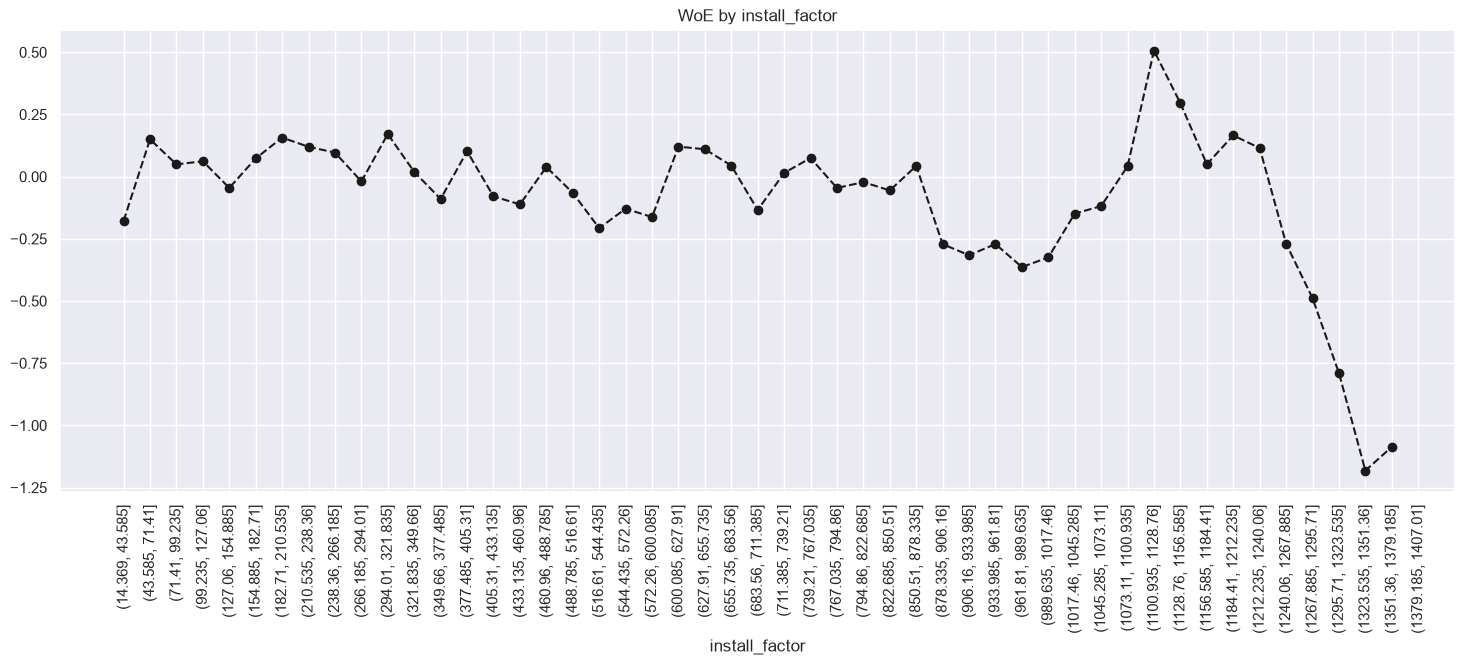

In [76]:
plot_by_woe(df_install, 90)

In [77]:
# 16 rev high limit 
df_input_prep['total_rev_hi_lim_factor'] = pd.cut(df_input_prep['total_rev_hi_lim'], 800)
df_revhi = woe_conti(df_input_prep, 'total_rev_hi_lim_factor', df_target_prep)
df_revhi

/opt/miniconda3/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-2013.133, 2516.416]",1375,0.837818,0.014744,1152.0,223.0,0.013868,0.021884,-0.456158,inf
1,"(2516.416, 5032.832]",4286,0.869109,0.045959,3725.0,561.0,0.044843,0.055054,-0.205139,inf
2,"(5032.832, 7549.249]",6018,0.873712,0.064531,5258.0,760.0,0.063298,0.074583,-0.164053,inf
3,"(7549.249, 10065.665]",7794,0.871824,0.083575,6795.0,999.0,0.081801,0.098037,-0.181053,inf
4,"(10065.665, 12582.081]",7125,0.880140,0.076402,6271.0,854.0,0.075493,0.083808,-0.104481,inf
...,...,...,...,...,...,...,...,...,...,...
175,"(900877.018, 903393.434]",1,1.000000,0.000011,1.0,0.0,0.000012,0.000000,inf,inf
176,"(1029214.246, 1031730.663]",1,1.000000,0.000011,1.0,0.0,0.000012,0.000000,inf,inf
177,"(1059411.241, 1061927.658]",1,1.000000,0.000011,1.0,0.0,0.000012,0.000000,inf,inf
178,"(1089608.236, 1092124.652]",1,1.000000,0.000011,1.0,0.0,0.000012,0.000000,inf,inf


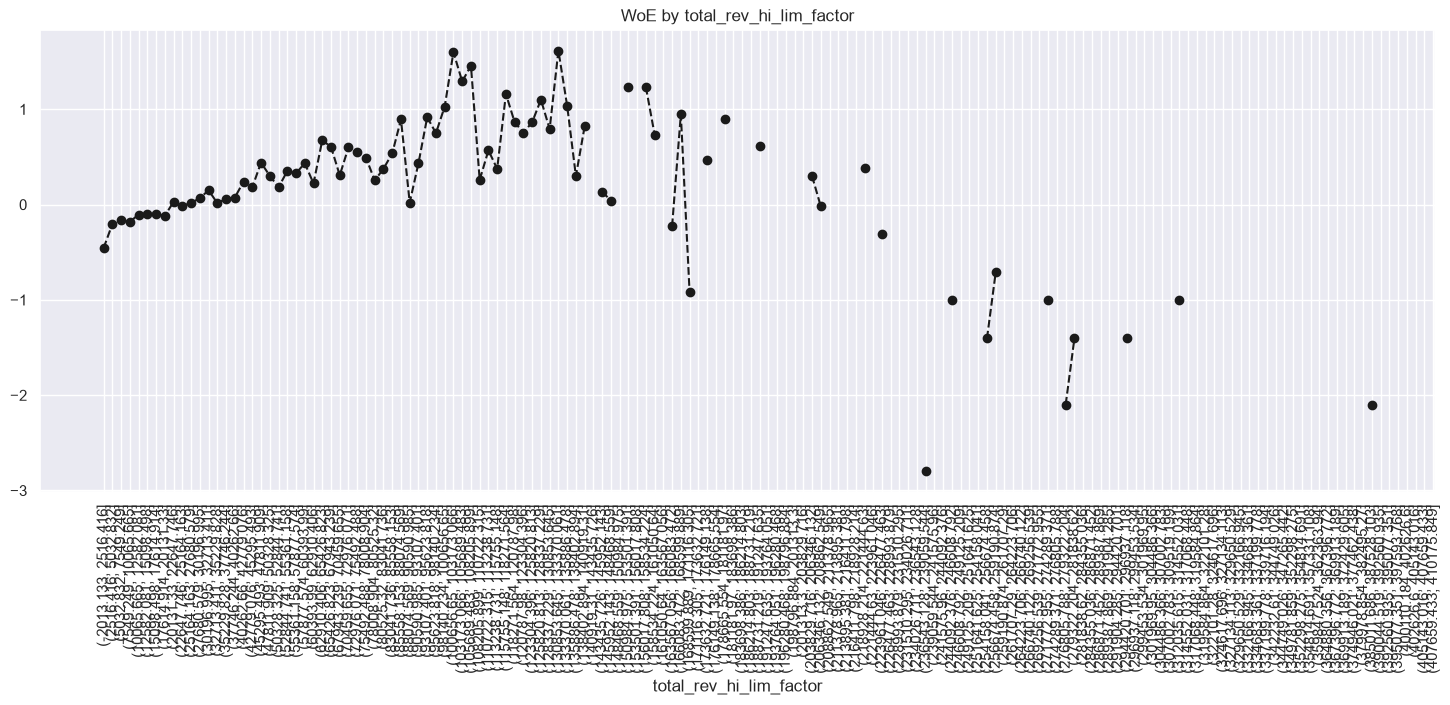

In [78]:
plot_by_woe(df_revhi, 90)

In [79]:
df_input_prep['total_revhi_lim_<=5K'] = np.where((df_input_prep['total_rev_hi_lim'] <= 5000), 1, 0)
df_input_prep['total_revhi_lim_5K-10K'] = np.where((df_input_prep['total_rev_hi_lim'] > 5000) & (df_input_prep['total_rev_hi_lim'] <= 10000), 1, 0)
df_input_prep['total_revhi_lim_10K-20K'] = np.where((df_input_prep['total_rev_hi_lim'] > 10000) & (df_input_prep['total_rev_hi_lim'] <= 20000), 1, 0)
df_input_prep['total_revhi_lim_20K-30K'] = np.where((df_input_prep['total_rev_hi_lim'] > 20000) & (df_input_prep['total_rev_hi_lim'] <= 30000), 1, 0)
df_input_prep['total_revhi_lim_30K-40K'] = np.where((df_input_prep['total_rev_hi_lim'] > 30000) & (df_input_prep['total_rev_hi_lim'] <= 40000), 1, 0)
df_input_prep['total_revhi_lim_40K-55K'] = np.where((df_input_prep['total_rev_hi_lim'] > 40000) & (df_input_prep['total_rev_hi_lim'] <= 55000), 1, 0)
df_input_prep['total_revhi_lim_55K-95K'] = np.where((df_input_prep['total_rev_hi_lim'] > 55000) & (df_input_prep['total_rev_hi_lim'] <= 95000), 1, 0)
df_input_prep['total_revhi_lim_>95K'] = np.where((df_input_prep['total_rev_hi_lim'] > 95000), 1, 0)

In [80]:
# 17. total acc
# e =df_input_prep['total_acc'].unique() # ~160
df_input_prep['total_acc_factor'] = pd.cut(df_input_prep['total_acc'],50)
df_total_acc = woe_conti(df_input_prep, 'total_acc_factor', df_target_prep)
df_total_acc
#some intervals have 0 obs

,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.156, 3.12]",125,0.776000,0.001340,97.0,28.0,0.001168,0.002748,-0.855734,inf
1,"(3.12, 6.24]",1499,0.850567,0.016074,1275.0,224.0,0.015349,0.021982,-0.359185,inf
2,"(6.24, 9.36]",3715,0.871871,0.039836,3239.0,476.0,0.038993,0.046712,-0.180639,inf
3,"(9.36, 12.48]",6288,0.874841,0.067427,5501.0,787.0,0.066224,0.077233,-0.153784,inf
4,"(12.48, 15.6]",8289,0.888286,0.088883,7363.0,926.0,0.088639,0.090873,-0.024892,inf
5,"(15.6, 18.72]",9843,0.890176,0.105547,8762.0,1081.0,0.105481,0.106084,-0.005703,inf
6,"(18.72, 21.84]",10270,0.893866,0.110126,9180.0,1090.0,0.110513,0.106968,0.032609,inf
7,"(21.84, 24.96]",9971,0.892789,0.106920,8902.0,1069.0,0.107167,0.104907,0.021312,inf
8,"(24.96, 28.08]",11873,0.892108,0.127315,10592.0,1281.0,0.127512,0.125711,0.014217,inf
9,"(28.08, 31.2]",7289,0.892715,0.078160,6507.0,782.0,0.078334,0.076742,0.020538,inf


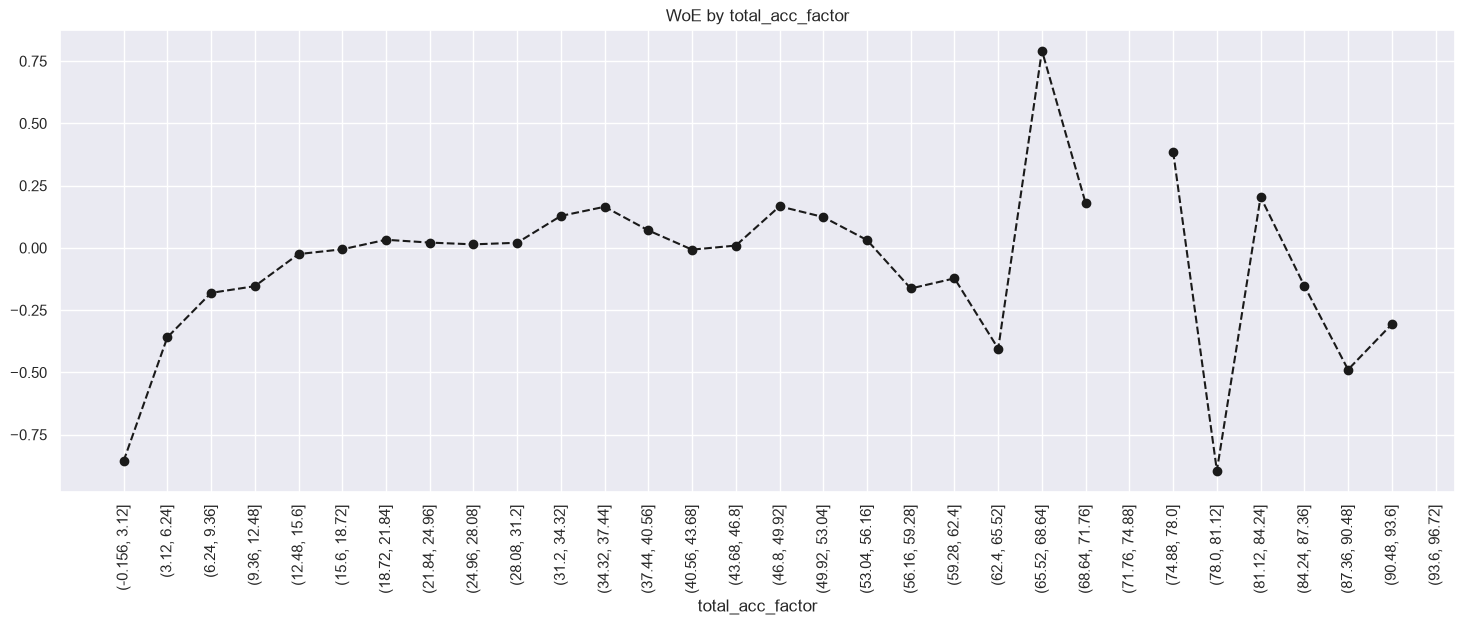

In [81]:
plot_by_woe(df_total_acc, 90)

In [82]:
# Different than the program assigned
df_input_prep['total_acc_<=27'] = np.where((df_input_prep['total_acc']<=27),1,0)
df_input_prep['total_acc_27-48'] = np.where((df_input_prep['total_acc']> 27)&(df_input_prep['total_acc']<=48),1,0)
df_input_prep['total_acc_48-60'] = np.where((df_input_prep['total_acc']> 48)&(df_input_prep['total_acc']<=60),1,0)
df_input_prep['total_acc_>60'] = np.where((df_input_prep['total_acc']> 60),1,0)

In [83]:
# course
# 18. annual income
df_input_prep['annual_inc_factor'] = pd.cut(df_input_prep['annual_inc'],100)
df_annual = woe_conti(df_input_prep, 'annual_inc_factor', df_target_prep)
df_annual

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-2695.2, 79752.0]",62621,0.877932,0.671488,54977.0,7644.0,0.661839,0.750147,-0.125247,inf
1,"(79752.0, 154704.0]",26582,0.915206,0.285040,24328.0,2254.0,0.292872,0.221197,0.280681,inf
2,"(154704.0, 229656.0]",2916,0.926269,0.031268,2701.0,215.0,0.032516,0.021099,0.432499,inf
3,"(229656.0, 304608.0]",710,0.928169,0.007613,659.0,51.0,0.007933,0.005005,0.460657,inf
4,"(304608.0, 379560.0]",171,0.929825,0.001834,159.0,12.0,0.001914,0.001178,0.485757,inf
5,"(379560.0, 454512.0]",111,0.927928,0.001190,103.0,8.0,0.001240,0.000785,0.457047,inf
6,"(454512.0, 529464.0]",53,0.962264,0.000568,51.0,2.0,0.000614,0.000196,1.140438,inf
7,"(529464.0, 604416.0]",33,0.969697,0.000354,32.0,1.0,0.000385,0.000098,1.367495,inf
8,"(604416.0, 679368.0]",10,1.000000,0.000107,10.0,0.0,0.000120,0.000000,inf,inf
9,"(679368.0, 754320.0]",13,0.923077,0.000139,12.0,1.0,0.000144,0.000098,0.386666,inf


In [84]:
df_input_prep_temp = df_input_prep.loc[df_input_prep['annual_inc']<=140000,:]
df_input_prep_temp['annual_inc_factor'] = pd.cut(df_input_prep_temp['annual_inc'],50)
df_annual_temp = woe_conti(df_input_prep_temp, 'annual_inc_factor', df_target_prep[df_input_prep_temp.index])
df_annual_temp

,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(4664.8, 7504.0]",10,1.000000,0.000114,10.0,0.0,0.000128,0.000000,inf,inf
1,"(7504.0, 10208.0]",84,0.761905,0.000958,64.0,20.0,0.000822,0.002043,-0.911157,inf
2,"(10208.0, 12912.0]",123,0.780488,0.001403,96.0,27.0,0.001232,0.002758,-0.805796,inf
3,"(12912.0, 15616.0]",304,0.851974,0.003467,259.0,45.0,0.003325,0.004597,-0.324142,inf
4,"(15616.0, 18320.0]",383,0.827676,0.004368,317.0,66.0,0.004069,0.006743,-0.505060,inf
5,"(18320.0, 21024.0]",733,0.840382,0.008359,616.0,117.0,0.007907,0.011953,-0.413234,inf
6,"(21024.0, 23728.0]",704,0.846591,0.008028,596.0,108.0,0.007651,0.011034,-0.366198,inf
7,"(23728.0, 26432.0]",1785,0.861064,0.020356,1537.0,248.0,0.019730,0.025337,-0.250148,inf
8,"(26432.0, 29136.0]",1355,0.853137,0.015452,1156.0,199.0,0.014839,0.020331,-0.314891,inf
9,"(29136.0, 31840.0]",2292,0.854276,0.026137,1958.0,334.0,0.025134,0.034123,-0.305769,inf


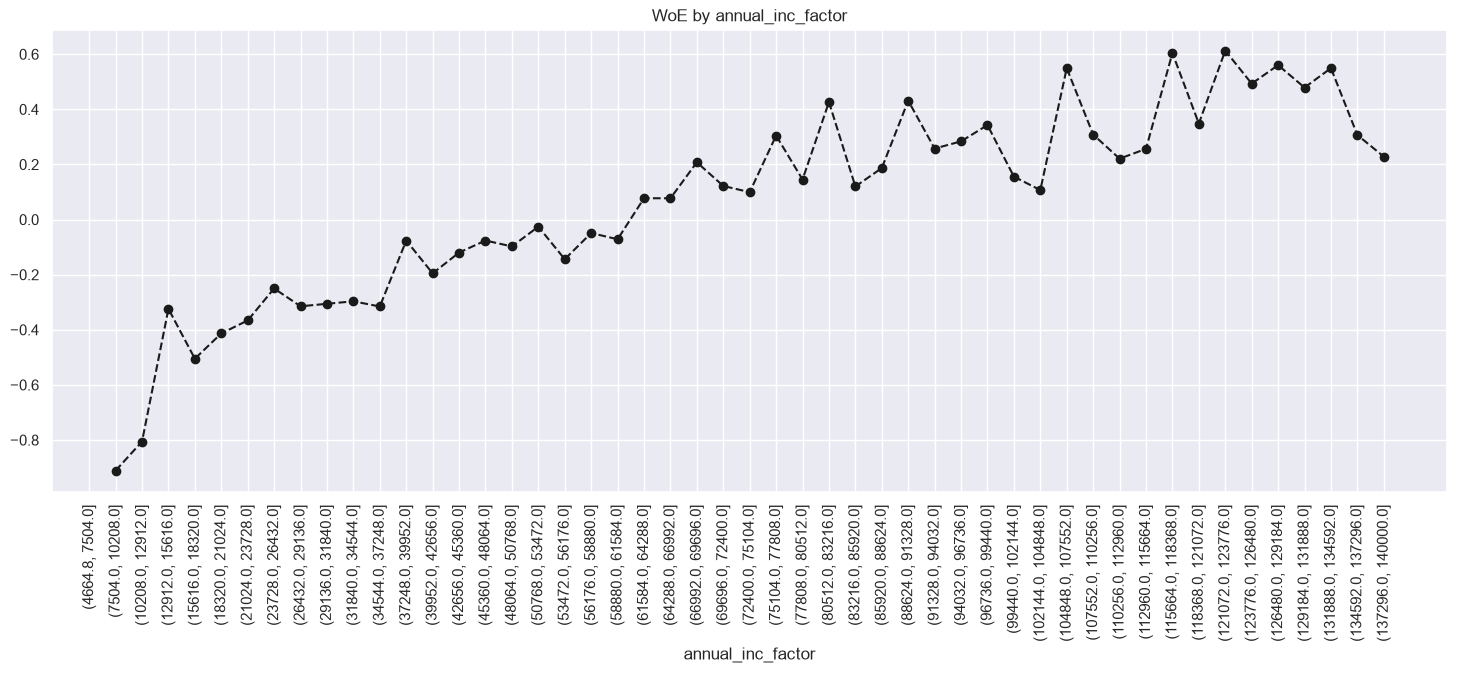

In [85]:
plot_by_woe(df_annual_temp, 90)

In [86]:
df_input_prep['annual_inc_<=20']=np.where((df_input_prep['annual_inc']<=20000),1,0)
df_input_prep['annual_inc_20-30']=np.where((df_input_prep['annual_inc']>20000)&(df_input_prep['annual_inc']<=30000),1,0)
df_input_prep['annual_inc_30-40']=np.where((df_input_prep['annual_inc']>30000)&(df_input_prep['annual_inc']<=40000),1,0)
df_input_prep['annual_inc_40-50']=np.where((df_input_prep['annual_inc']>40000)&(df_input_prep['annual_inc']<=50000),1,0)
df_input_prep['annual_inc_50-60']=np.where((df_input_prep['annual_inc']>50000)&(df_input_prep['annual_inc']<=60000),1,0)
df_input_prep['annual_inc_60-70']=np.where((df_input_prep['annual_inc']>60000)&(df_input_prep['annual_inc']<=70000),1,0)
df_input_prep['annual_inc_70-80']=np.where((df_input_prep['annual_inc']>70000)&(df_input_prep['annual_inc']<=80000),1,0)
df_input_prep['annual_inc_80-90']=np.where((df_input_prep['annual_inc']>80000)&(df_input_prep['annual_inc']<=90000),1,0)
df_input_prep['annual_inc_90-100']=np.where((df_input_prep['annual_inc']>90000)&(df_input_prep['annual_inc']<=100000),1,0)
df_input_prep['annual_inc_100-120']=np.where((df_input_prep['annual_inc']>100000)&(df_input_prep['annual_inc']<=120000),1,0)
df_input_prep['annual_inc_120-140']=np.where((df_input_prep['annual_inc']>120000)&(df_input_prep['annual_inc']<=140000),1,0)
df_input_prep['annual_inc_>140']=np.where((df_input_prep['annual_inc']>140000),1,0)

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/3649580479.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['annual_inc_<=20']=np.where((df_input_prep['annual_inc']<=20000),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/3649580479.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['annual_inc_20-30']=np.where((df_input_prep['annual_inc']>20000)&(df_input_prep['annual_inc']<=30000),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/36495804

In [87]:
# deal with the missing dummies
# 19. mths_since_last_delinq
# 1 as missing, and 0 for not missing
df_input_prep_temp = df_input_prep[pd.notnull(df_input_prep['mths_since_last_delinq'])]
df_input_prep_temp['mths_since_last_delinq_factor'] = pd.cut(df_input_prep_temp['mths_since_last_delinq'],50)
df_mth_delinq_temp = woe_conti(df_input_prep_temp, 'mths_since_last_delinq_factor', df_target_prep[df_input_prep_temp.index])
df_mth_delinq_temp

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/1455060115.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep_temp['mths_since_last_delinq_factor'] = pd.cut(df_input_prep_temp['mths_since_last_delinq'],50)


,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.17, 3.4]",1348,0.868694,0.031283,1171.0,177.0,0.030501,0.037668,-0.211036,inf
1,"(3.4, 6.8]",1890,0.880423,0.043861,1664.0,226.0,0.043342,0.048095,-0.104055,inf
2,"(6.8, 10.2]",3373,0.887044,0.078276,2992.0,381.0,0.077933,0.081081,-0.039601,inf
3,"(10.2, 13.6]",2496,0.895833,0.057924,2236.0,260.0,0.058241,0.055331,0.051263,inf
4,"(13.6, 17.0]",3165,0.884044,0.073449,2798.0,367.0,0.072880,0.078102,-0.069201,inf
5,"(17.0, 20.4]",2282,0.893076,0.052958,2038.0,244.0,0.053084,0.051926,0.022057,inf
6,"(20.4, 23.8]",2115,0.898345,0.049082,1900.0,215.0,0.049489,0.045754,0.078472,inf
7,"(23.8, 27.2]",2755,0.895463,0.063934,2467.0,288.0,0.064258,0.061290,0.047298,inf
8,"(27.2, 30.6]",1929,0.896319,0.044766,1729.0,200.0,0.045035,0.042562,0.056482,inf
9,"(30.6, 34.0]",2453,0.891969,0.056926,2188.0,265.0,0.056991,0.056395,0.010514,inf


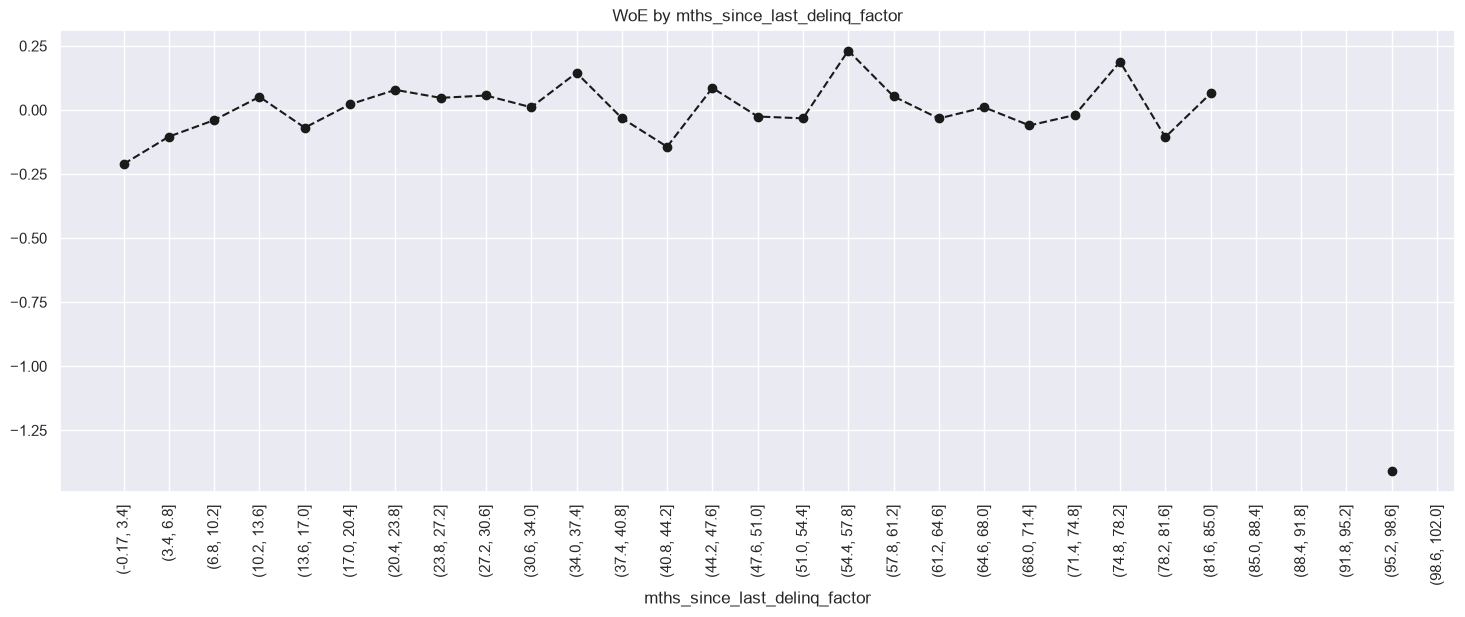

In [88]:
plot_by_woe(df_mth_delinq_temp, 90)

In [89]:
df_input_prep['mths_since_last_delinq_missing'] = np.where((df_input_prep['mths_since_last_delinq'].isnull()),1,0)
df_input_prep['mths_since_last_delinq_0-3'] = np.where((df_input_prep['mths_since_last_delinq']>=0)&(df_input_prep['mths_since_last_delinq']<=3),1,0)
df_input_prep['mths_since_last_delinq_4-30'] = np.where((df_input_prep['mths_since_last_delinq']>=3)&(df_input_prep['mths_since_last_delinq']<=30),1,0)
df_input_prep['mths_since_last_delinq_31-56'] = np.where((df_input_prep['mths_since_last_delinq']>=31)&(df_input_prep['mths_since_last_delinq']<=56),1,0)
df_input_prep['mths_since_last_delinq_>=57'] = np.where((df_input_prep['mths_since_last_delinq']>=57),1,0)


/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2212133452.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_last_delinq_missing'] = np.where((df_input_prep['mths_since_last_delinq'].isnull()),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2212133452.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_last_delinq_0-3'] = np.where((df_input_prep['mths_since_last_delinq']>=0)&(df_input_prep['mths_since_last_delinq']<=3),1,0)
/var/folders/

In [90]:
df_input_prep['dti'].isna().count()

np.int64(93257)

In [91]:
#homework
# 20. dti(debt to income ratio)
df_input_prep_temp = df_input_prep[pd.notnull(df_input_prep['dti'])]
df_input_prep_temp['dti_factor'] = pd.cut(df_input_prep_temp['dti'],50)
df_dti_temp = woe_conti(df_input_prep_temp, 'dti_factor', df_target_prep[df_input_prep_temp.index])
df_dti_temp

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/3058875730.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep_temp['dti_factor'] = pd.cut(df_input_prep_temp['dti'],50)


,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.04, 0.8]",371,0.886792,0.003978,329.0,42.0,0.003961,0.004122,-0.039853,0.032501
1,"(0.8, 1.6]",478,0.899582,0.005126,430.0,48.0,0.005177,0.004711,0.094344,0.032501
2,"(1.6, 2.399]",639,0.902973,0.006852,577.0,62.0,0.006946,0.006084,0.132467,0.032501
3,"(2.399, 3.199]",808,0.912129,0.008664,737.0,71.0,0.008872,0.006968,0.241667,0.032501
4,"(3.199, 3.999]",1047,0.916905,0.011227,960.0,87.0,0.011557,0.008538,0.302785,0.032501
5,"(3.999, 4.799]",1260,0.912698,0.013511,1150.0,110.0,0.013844,0.010795,0.248796,0.032501
6,"(4.799, 5.599]",1527,0.912901,0.016374,1394.0,133.0,0.016782,0.013052,0.251343,0.032501
7,"(5.599, 6.398]",1730,0.905202,0.018551,1566.0,164.0,0.018852,0.016094,0.158173,0.032501
8,"(6.398, 7.198]",1999,0.919960,0.021435,1839.0,160.0,0.022139,0.015702,0.343563,0.032501
9,"(7.198, 7.998]",2227,0.908846,0.023880,2024.0,203.0,0.024366,0.019921,0.201384,0.032501


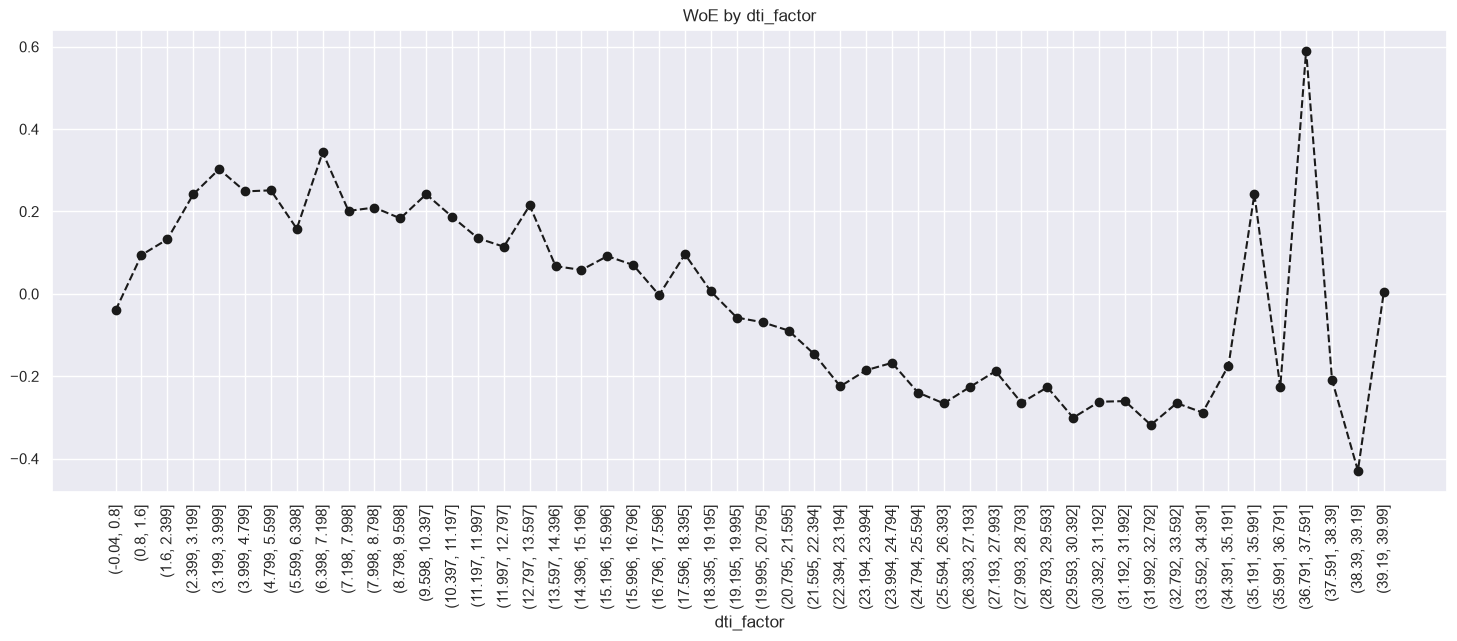

In [92]:
plot_by_woe(df_dti_temp, 90)

In [93]:
# <=1.6, 1.6-8.8, 8.8-15.2, 15.2-16, 16-20.8,20.8-27.2, >=27.2
df_input_prep['dti_missing'] = np.where((df_input_prep['dti'].isnull()),1,0)
df_input_prep['dti_<=1.6']= np.where((df_input_prep['dti'] <=1.6),1,0)
df_input_prep['dti_1.6-4']= np.where((df_input_prep['dti'] > 1.6) & (df_input_prep['dti'] <= 4), 1, 0)
df_input_prep['dti_4-8.8']= np.where((df_input_prep['dti'] > 4) & (df_input_prep['dti'] <= 8.8), 1, 0)
df_input_prep['dti_8.8-12']= np.where((df_input_prep['dti'] > 8.8) & (df_input_prep['dti'] <= 12), 1, 0)
df_input_prep['dti_12-16']= np.where((df_input_prep['dti'] > 12) & (df_input_prep['dti'] <= 16), 1, 0)
df_input_prep['dti_16-20.8']= np.where((df_input_prep['dti'] > 16) & (df_input_prep['dti'] <= 20.8), 1, 0)
df_input_prep['dti_20.8-24']= np.where((df_input_prep['dti'] > 20.8) & (df_input_prep['dti'] <= 24), 1, 0)
df_input_prep['dti_24-35']= np.where((df_input_prep['dti'] > 24) & (df_input_prep['dti'] <= 35), 1, 0)
df_input_prep['dti_>35']= np.where(df_input_prep['dti'] > 35, 1, 0)

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2083085678.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['dti_missing'] = np.where((df_input_prep['dti'].isnull()),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2083085678.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['dti_<=1.6']= np.where((df_input_prep['dti'] <=1.6),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2083085678.py:4: PerformanceWarning: DataFrame is highly fragment

In [94]:
# 21 ‘mths_since_last_record’
df_input_prep['mths_since_last_record'].isna().sum()


np.int64(80686)

In [95]:
df_input_prep['mths_since_last_record'].notna().sum()

np.int64(12571)

In [96]:
df_input_prep_temp = df_input_prep[pd.notnull(df_input_prep['mths_since_last_record'])]
df_input_prep_temp['mths_since_last_record_factor'] = pd.cut(df_input_prep_temp['mths_since_last_record'],50)
df_sincelastrec_temp = woe_conti(df_input_prep_temp, 'mths_since_last_record_factor', df_target_prep[df_input_prep_temp.index])
df_sincelastrec_temp

/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2577003720.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep_temp['mths_since_last_record_factor'] = pd.cut(df_input_prep_temp['mths_since_last_record'],50)
/opt/miniconda3/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,"(-0.129, 2.58]",244,0.741803,0.019410,181.0,63.0,0.016036,0.049065,-1.118309,inf
1,"(2.58, 5.16]",36,0.888889,0.002864,32.0,4.0,0.002835,0.003115,-0.094230,inf
2,"(5.16, 7.74]",39,0.923077,0.003102,36.0,3.0,0.003190,0.002336,0.311235,inf
3,"(7.74, 10.32]",66,0.939394,0.005250,62.0,4.0,0.005493,0.003115,0.567169,inf
4,"(10.32, 12.9]",42,0.833333,0.003341,35.0,7.0,0.003101,0.005452,-0.564234,inf
5,"(12.9, 15.48]",69,0.869565,0.005489,60.0,9.0,0.005316,0.007009,-0.276551,inf
6,"(15.48, 18.06]",95,0.863158,0.007557,82.0,13.0,0.007265,0.010125,-0.331902,inf
7,"(18.06, 20.64]",58,0.965517,0.004614,56.0,2.0,0.004961,0.001558,1.158533,inf
8,"(20.64, 23.22]",101,0.891089,0.008034,90.0,11.0,0.007974,0.008567,-0.071757,inf
9,"(23.22, 25.8]",94,0.946809,0.007478,89.0,5.0,0.007885,0.003894,0.705527,inf


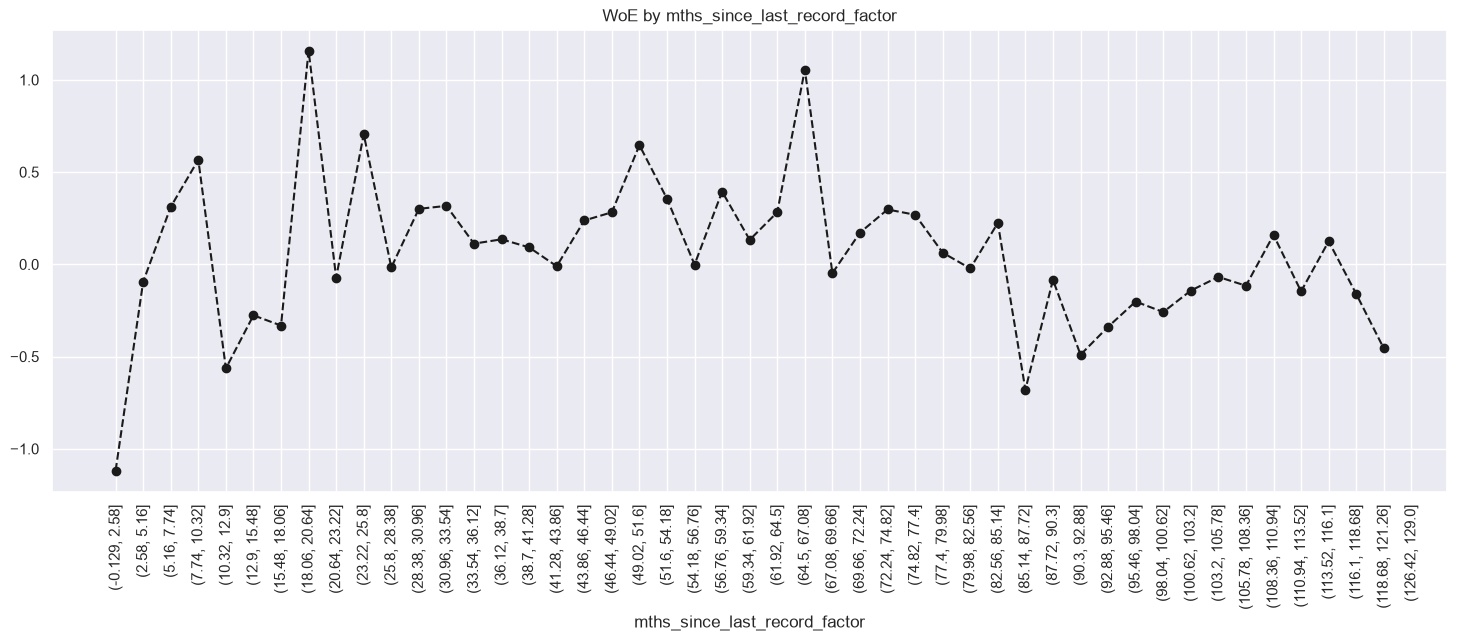

In [97]:
plot_by_woe(df_sincelastrec_temp, 90)

In [98]:
# slightly different from the course 
# <=2.42, 2.42-19.36, 19.36-31.46, 31.46-50.82, 50.82-79.86, >79.86
df_input_prep['mths_since_lst_missing'] = np.where((df_input_prep['mths_since_last_record'].isnull()),1,0)
df_input_prep['mths_since_lst_<=2.42'] =np.where((df_input_prep['mths_since_last_record']>=0)&(df_input_prep['mths_since_last_record'] <= 2.42), 1, 0)
df_input_prep['mths_since_lst_2.42-19.36'] =np.where((df_input_prep['mths_since_last_record'] > 2.42) & (df_input_prep['mths_since_last_record'] <= 19.36), 1, 0)
df_input_prep['mths_since_lst_19.36-31.46'] =np.where((df_input_prep['mths_since_last_record'] > 2.42) & (df_input_prep['mths_since_last_record'] <= 31.46), 1, 0)
df_input_prep['mths_since_lst_31.46-50.82'] =np.where((df_input_prep['mths_since_last_record'] > 31.46) & (df_input_prep['mths_since_last_record'] <= 50.82), 1, 0)
df_input_prep['mths_since_lst_50.82-79.86'] =np.where((df_input_prep['mths_since_last_record'] > 50.82) & (df_input_prep['mths_since_last_record'] <= 79.86), 1, 0)
df_input_prep['mths_since_lst_>79.86'] = np.where(df_input_prep['mths_since_last_record'] > 79.86, 1, 0)


/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2134846294.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_lst_missing'] = np.where((df_input_prep['mths_since_last_record'].isnull()),1,0)
/var/folders/c5/wvvvdbz52918llrn89472ywr0000gp/T/ipykernel_29493/2134846294.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_input_prep['mths_since_lst_<=2.42'] =np.where((df_input_prep['mths_since_last_record']>=0)&(df_input_prep['mths_since_last_record'] <= 2.42), 1, 0)
/var/folders/c5/wvvv

In [99]:
df_input_prep.to_pickle('/Users/eileending/Downloads/loan_data_input_test.pkl')